# NumPy, Pandas & Matplotlib Integration Challenge


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_ind, chi2_contingency
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

print("Libraries imported successfully!")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")

Libraries imported successfully!
NumPy version: 2.3.3
Pandas version: 2.3.3
Matplotlib version: 3.10.7
Seaborn version: 0.13.2


## Task 1: Data Import and Cleaning

Let's start by importing the dataset and examining its structure, then handle missing values using NumPy and Pandas.

In [3]:
df = pd.read_csv('global_power_plant_database.csv', low_memory=False)

print("Dataset Overview:")
print(f"Shape: {df.shape}")
print(f"Columns: {len(df.columns)}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\n" + "="*50)
print("DATASET STRUCTURE")
print("="*50)
print(df.info())

print("\n" + "="*50)
print("FIRST FEW ROWS")
print("="*50)
df.head()

Dataset Overview:
Shape: (34936, 36)
Columns: 36
Memory usage: 41.54 MB

DATASET STRUCTURE
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34936 entries, 0 to 34935
Data columns (total 36 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   country                         34936 non-null  object 
 1   country_long                    34936 non-null  object 
 2   name                            34936 non-null  object 
 3   gppd_idnr                       34936 non-null  object 
 4   capacity_mw                     34936 non-null  float64
 5   latitude                        34936 non-null  float64
 6   longitude                       34936 non-null  float64
 7   primary_fuel                    34936 non-null  object 
 8   other_fuel1                     1944 non-null   object 
 9   other_fuel2                     276 non-null    object 
 10  other_fuel3                     92 non-null     object 
 11  co

,country,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,primary_fuel,other_fuel1,other_fuel2,other_fuel3,commissioning_year,owner,source,url,geolocation_source,wepp_id,year_of_capacity_data,generation_gwh_2013,generation_gwh_2014,generation_gwh_2015,generation_gwh_2016,generation_gwh_2017,generation_gwh_2018,generation_gwh_2019,generation_data_source,estimated_generation_gwh_2013,estimated_generation_gwh_2014,estimated_generation_gwh_2015,estimated_generation_gwh_2016,estimated_generation_gwh_2017,estimated_generation_note_2013,estimated_generation_note_2014,estimated_generation_note_2015,estimated_generation_note_2016,estimated_generation_note_2017
0,AFG,Afghanistan,Kajaki Hydroelectric Power Plant Afghanistan,GEODB0040538,33.0,32.322,65.1190,Hydro,NaN,NaN,NaN,NaN,NaN,GEODB,http://globalenergyobservatory.org,GEODB,1009793,2017.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,123.77,162.90,97.39,137.76,119.50,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
1,AFG,Afghanistan,Kandahar DOG,WKS0070144,10.0,31.670,65.7950,Solar,NaN,NaN,NaN,NaN,NaN,Wiki-Solar,https://www.wiki-solar.org,Wiki-Solar,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.43,17.48,18.25,17.70,18.29,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
2,AFG,Afghanistan,Kandahar JOL,WKS0071196,10.0,31.623,65.7920,Solar,NaN,NaN,NaN,NaN,NaN,Wiki-Solar,https://www.wiki-solar.org,Wiki-Solar,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.64,17.58,19.10,17.62,18.72,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
3,AFG,Afghanistan,Mahipar Hydroelectric Power Plant Afghanistan,GEODB0040541,66.0,34.556,69.4787,Hydro,NaN,NaN,NaN,NaN,NaN,GEODB,http://globalenergyobservatory.org,GEODB,1009795,2017.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,225.06,203.55,146.90,230.18,174.91,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
4,AFG,Afghanistan,Naghlu Dam Hydroelectric Power Plant Afghanistan,GEODB0040534,100.0,34.641,69.7170,Hydro,NaN,NaN,NaN,NaN,NaN,GEODB,http://globalenergyobservatory.org,GEODB,1009797,2017.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,406.16,357.22,270.99,395.38,350.80,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1


MISSING VALUES ANALYSIS
Columns with missing values: 23

Top 10 columns with highest missing percentages:
                 Column  Missing_Count  Missing_Percentage
10          other_fuel3          34844           99.736661
9           other_fuel2          34660           99.209984
8           other_fuel1          32992           94.435539
18  generation_gwh_2013          28519           81.632127
19  generation_gwh_2014          27710           79.316464
20  generation_gwh_2015          26733           76.519922
21  generation_gwh_2016          25792           73.826425
22  generation_gwh_2017          25436           72.807419
23  generation_gwh_2018          25299           72.415274
24  generation_gwh_2019          25277           72.352301


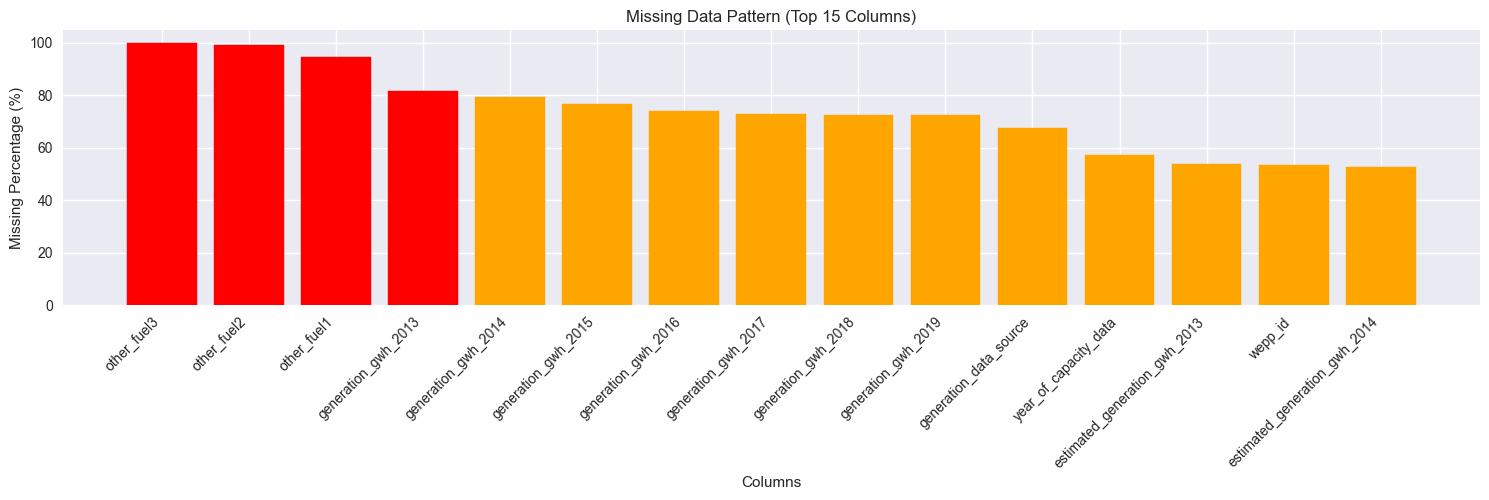


NumPy Analysis of Missing Values:
Total missing values: 455857
Percentage of missing values: 36.25%


In [4]:
#  missing values using NumPy and Pandas
print("MISSING VALUES ANALYSIS")
print("="*50)

# count missing values
missing_data = df.isnull().sum()
missing_percentage = (missing_data / len(df)) * 100

missing_summary = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': missing_data.values,
    'Missing_Percentage': missing_percentage.values
})

missing_summary = missing_summary[missing_summary['Missing_Count'] > 0]
missing_summary = missing_summary.sort_values('Missing_Percentage', ascending=False)

print(f"Columns with missing values: {len(missing_summary)}")
print("\nTop 10 columns with highest missing percentages:")
print(missing_summary.head(10))

plt.figure(figsize=(15, 8))
plt.subplot(2, 1, 1)
missing_summary_top = missing_summary.head(15)
bars = plt.bar(range(len(missing_summary_top)), missing_summary_top['Missing_Percentage'])
plt.xlabel('Columns')
plt.ylabel('Missing Percentage (%)')
plt.title('Missing Data Pattern (Top 15 Columns)')
plt.xticks(range(len(missing_summary_top)), missing_summary_top['Column'], rotation=45, ha='right')

# Color bars based on missing percentage
for i, bar in enumerate(bars):
    if missing_summary_top.iloc[i]['Missing_Percentage'] > 80:
        bar.set_color('red')
    elif missing_summary_top.iloc[i]['Missing_Percentage'] > 50:
        bar.set_color('orange')
    else:
        bar.set_color('lightblue')

plt.tight_layout()
plt.show()

print("\nNumPy Analysis of Missing Values:")
print(f"Total missing values: {np.sum(df.isnull().values)}")
print(f"Percentage of missing values: {np.mean(df.isnull().values) * 100:.2f}%")

In [5]:
#  Handle missing values and convert data types
print("DATA CLEANING PROCESS")
print("="*50)

df_clean = df.copy()

# Key numerical columns 
numerical_cols = ['capacity_mw', 'latitude', 'longitude', 'commissioning_year']
generation_cols = [col for col in df.columns if 'generation_gwh' in col and 'estimated' not in col]

print(f"Key numerical columns: {numerical_cols}")
print(f"Generation columns: {generation_cols}")

# Convert data type
print("\nConverting data types...")

df_clean['capacity_mw'] = pd.to_numeric(df_clean['capacity_mw'], errors='coerce')

# Convert to float
df_clean['latitude'] = pd.to_numeric(df_clean['latitude'], errors='coerce')
df_clean['longitude'] = pd.to_numeric(df_clean['longitude'], errors='coerce')

# Convert to integer
df_clean['commissioning_year'] = pd.to_numeric(df_clean['commissioning_year'], errors='coerce')

#  Convert to float
for col in generation_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# Handle missing values 
print("\nHandling missing values...")

# Remove rows with missing critical information
critical_cols = ['capacity_mw', 'primary_fuel', 'country']
before_cleaning = len(df_clean)

# Remove rows where all critical columns are missing
df_clean = df_clean.dropna(subset=critical_cols, how='all')

# Remove rows with missing capacity 
df_clean = df_clean.dropna(subset=['capacity_mw'])

after_cleaning = len(df_clean)
print(f"Rows removed: {before_cleaning - after_cleaning}")
print(f"Remaining rows: {after_cleaning}")

# Fill missing coordinates with country medians using NumPy
countries_with_coords = df_clean.dropna(subset=['latitude', 'longitude'])

# Calculate median coordinates by country
country_coords = countries_with_coords.groupby('country')[['latitude', 'longitude']].median()

print(f"\nFilling missing coordinates using country medians...")
coords_filled = 0

for country in df_clean['country'].unique():
    if country in country_coords.index:
        country_mask = (df_clean['country'] == country).values
        lat_missing = df_clean['latitude'].isnull().values
        lon_missing = df_clean['longitude'].isnull().values
        
        # Fill missing latitudes
        lat_fill_mask = country_mask & lat_missing
        if np.any(lat_fill_mask):
            df_clean.loc[lat_fill_mask, 'latitude'] = country_coords.loc[country, 'latitude']
            coords_filled += np.sum(lat_fill_mask)
        
        # Fill missing longitudes
        lon_fill_mask = country_mask & lon_missing
        if np.any(lon_fill_mask):
            df_clean.loc[lon_fill_mask, 'longitude'] = country_coords.loc[country, 'longitude']

print(f"Coordinates filled: {coords_filled}")

print(f"\nCLEANED DATASET SUMMARY")
print(f"Final shape: {df_clean.shape}")
print(f"Reduction: {((before_cleaning - after_cleaning) / before_cleaning * 100):.1f}%")

print("\nData types after cleaning:")
for col in numerical_cols + generation_cols[:3]:
    print(f"{col}: {df_clean[col].dtype}")

DATA CLEANING PROCESS
Key numerical columns: ['capacity_mw', 'latitude', 'longitude', 'commissioning_year']
Generation columns: ['generation_gwh_2013', 'generation_gwh_2014', 'generation_gwh_2015', 'generation_gwh_2016', 'generation_gwh_2017', 'generation_gwh_2018', 'generation_gwh_2019']

Converting data types...

Handling missing values...
Rows removed: 0
Remaining rows: 34936

Filling missing coordinates using country medians...
Coordinates filled: 0

CLEANED DATASET SUMMARY
Final shape: (34936, 36)
Reduction: 0.0%

Data types after cleaning:
capacity_mw: float64
latitude: float64
longitude: float64
commissioning_year: float64
generation_gwh_2013: float64
generation_gwh_2014: float64
generation_gwh_2015: float64
Coordinates filled: 0

CLEANED DATASET SUMMARY
Final shape: (34936, 36)
Reduction: 0.0%

Data types after cleaning:
capacity_mw: float64
latitude: float64
longitude: float64
commissioning_year: float64
generation_gwh_2013: float64
generation_gwh_2014: float64
generation_gwh_

## Task 2: Exploratory Data Analysis



In [6]:
print("EXPLORATORY DATA ANALYSIS")
print("="*70)

numerical_cols = ['capacity_mw', 'latitude', 'longitude', 'commissioning_year']

print("1. STATISTICAL SUMMARY FOR NUMERICAL COLUMNS")
print("-"*50)

stats_summary = pd.DataFrame(index=numerical_cols)

for col in numerical_cols:
    data = df_clean[col].dropna()
    
    stats_summary.loc[col, 'count'] = len(data)
    stats_summary.loc[col, 'mean'] = data.mean()
    stats_summary.loc[col, 'median'] = data.median()
    stats_summary.loc[col, 'std'] = data.std()
    
    stats_summary.loc[col, 'var'] = np.var(data)
    stats_summary.loc[col, 'skewness'] = stats.skew(data)
    stats_summary.loc[col, 'kurtosis'] = stats.kurtosis(data)
    stats_summary.loc[col, 'min'] = np.min(data)
    stats_summary.loc[col, 'max'] = np.max(data)
    stats_summary.loc[col, 'range'] = np.ptp(data)  # Peak-to-peak (range)
    stats_summary.loc[col, 'q25'] = np.percentile(data, 25)
    stats_summary.loc[col, 'q75'] = np.percentile(data, 75)
    stats_summary.loc[col, 'iqr'] = np.percentile(data, 75) - np.percentile(data, 25)

print(stats_summary.round(3))

print(f"\n2. ADVANCED NUMPY ANALYSIS - CAPACITY DISTRIBUTION")
print("-"*50)

capacity_data = df_clean['capacity_mw'].dropna().values

print(f"Array shape: {capacity_data.shape}")
print(f"Data type: {capacity_data.dtype}")
print(f"Memory usage: {capacity_data.nbytes / 1024:.2f} KB")

percentiles = np.array([1, 5, 10, 25, 50, 75, 90, 95, 99])
capacity_percentiles = np.percentile(capacity_data, percentiles)

percentile_df = pd.DataFrame({
    'Percentile': percentiles,
    'Capacity_MW': capacity_percentiles
})

print("\nCapacity Percentiles:")
print(percentile_df)

EXPLORATORY DATA ANALYSIS
1. STATISTICAL SUMMARY FOR NUMERICAL COLUMNS
--------------------------------------------------
                      count      mean    median      std         var  \
capacity_mw         34936.0   163.355    16.745  489.636  239736.620   
latitude            34936.0    32.817    39.728   22.639     512.492   
longitude           34936.0    -6.973    -2.127   78.406    6147.301   
commissioning_year  17447.0  1997.415  2007.000   23.398     547.427   

                    skewness  kurtosis       min        max      range  \
capacity_mw            8.899   192.913     1.000  22500.000  22499.000   
latitude              -1.609     1.956   -77.847     71.292    149.139   
longitude              0.290    -1.046  -179.978    179.389    359.366   
commissioning_year    -1.654     2.455  1896.000   2020.000    124.000   

                         q25       q75      iqr  
capacity_mw            4.900    75.344   70.444  
latitude              29.256    46.263   17.00

In [7]:
# Distribution analysis by country and fuel type
print("3. DISTRIBUTION ANALYSIS")
print("-"*50)

# Top countries by number of power plants
print("Top 15 Countries by Number of Power Plants:")
country_counts = df_clean['country'].value_counts().head(15)
print(country_counts)

# Top countries by total capacity using NumPy aggregation
print(f"\nTop 15 Countries by Total Capacity (MW):")
country_capacity = df_clean.groupby('country')['capacity_mw'].agg([
    ('total_capacity', 'sum'),
    ('avg_capacity', 'mean'),
    ('plant_count', 'count')
]).round(2)

country_capacity_sorted = country_capacity.sort_values('total_capacity', ascending=False).head(15)
print(country_capacity_sorted)

# Fuel type distribution
print(f"\nFuel Type Distribution:")
fuel_stats = df_clean['primary_fuel'].value_counts()
print(fuel_stats.head(10))

# Calculate fuel type statistics using NumPy
fuel_capacity_stats = df_clean.groupby('primary_fuel')['capacity_mw'].agg([
    ('total_capacity', lambda x: np.sum(x)),
    ('mean_capacity', lambda x: np.mean(x)),
    ('median_capacity', lambda x: np.median(x)),
    ('std_capacity', lambda x: np.std(x)),
    ('plant_count', 'count')
]).round(2)

fuel_capacity_stats_sorted = fuel_capacity_stats.sort_values('total_capacity', ascending=False).head(10)
print(f"\nTop 10 Fuel Types by Total Capacity:")
print(fuel_capacity_stats_sorted)

3. DISTRIBUTION ANALYSIS
--------------------------------------------------
Top 15 Countries by Number of Power Plants:
country
USA    9833
CHN    4235
GBR    2751
BRA    2360
FRA    2155
IND    1589
DEU    1309
CAN    1159
ESP     829
RUS     545
JPN     522
AUS     486
PRT     469
CZE     462
ITA     396
Name: count, dtype: int64

Top 15 Countries by Total Capacity (MW):
         total_capacity  avg_capacity  plant_count
country                                           
CHN          1415067.38        334.14         4235
USA          1204638.05        122.51         9833
IND           316088.55        198.92         1589
RUS           228220.05        418.75          545
JPN           215365.85        412.58          522
BRA           147589.27         62.54         2360
CAN           143578.70        123.88         1159
DEU           112040.37         85.59         1309
FRA           110615.93         51.33         2155
KOR            99472.68        753.58          132
GBR         

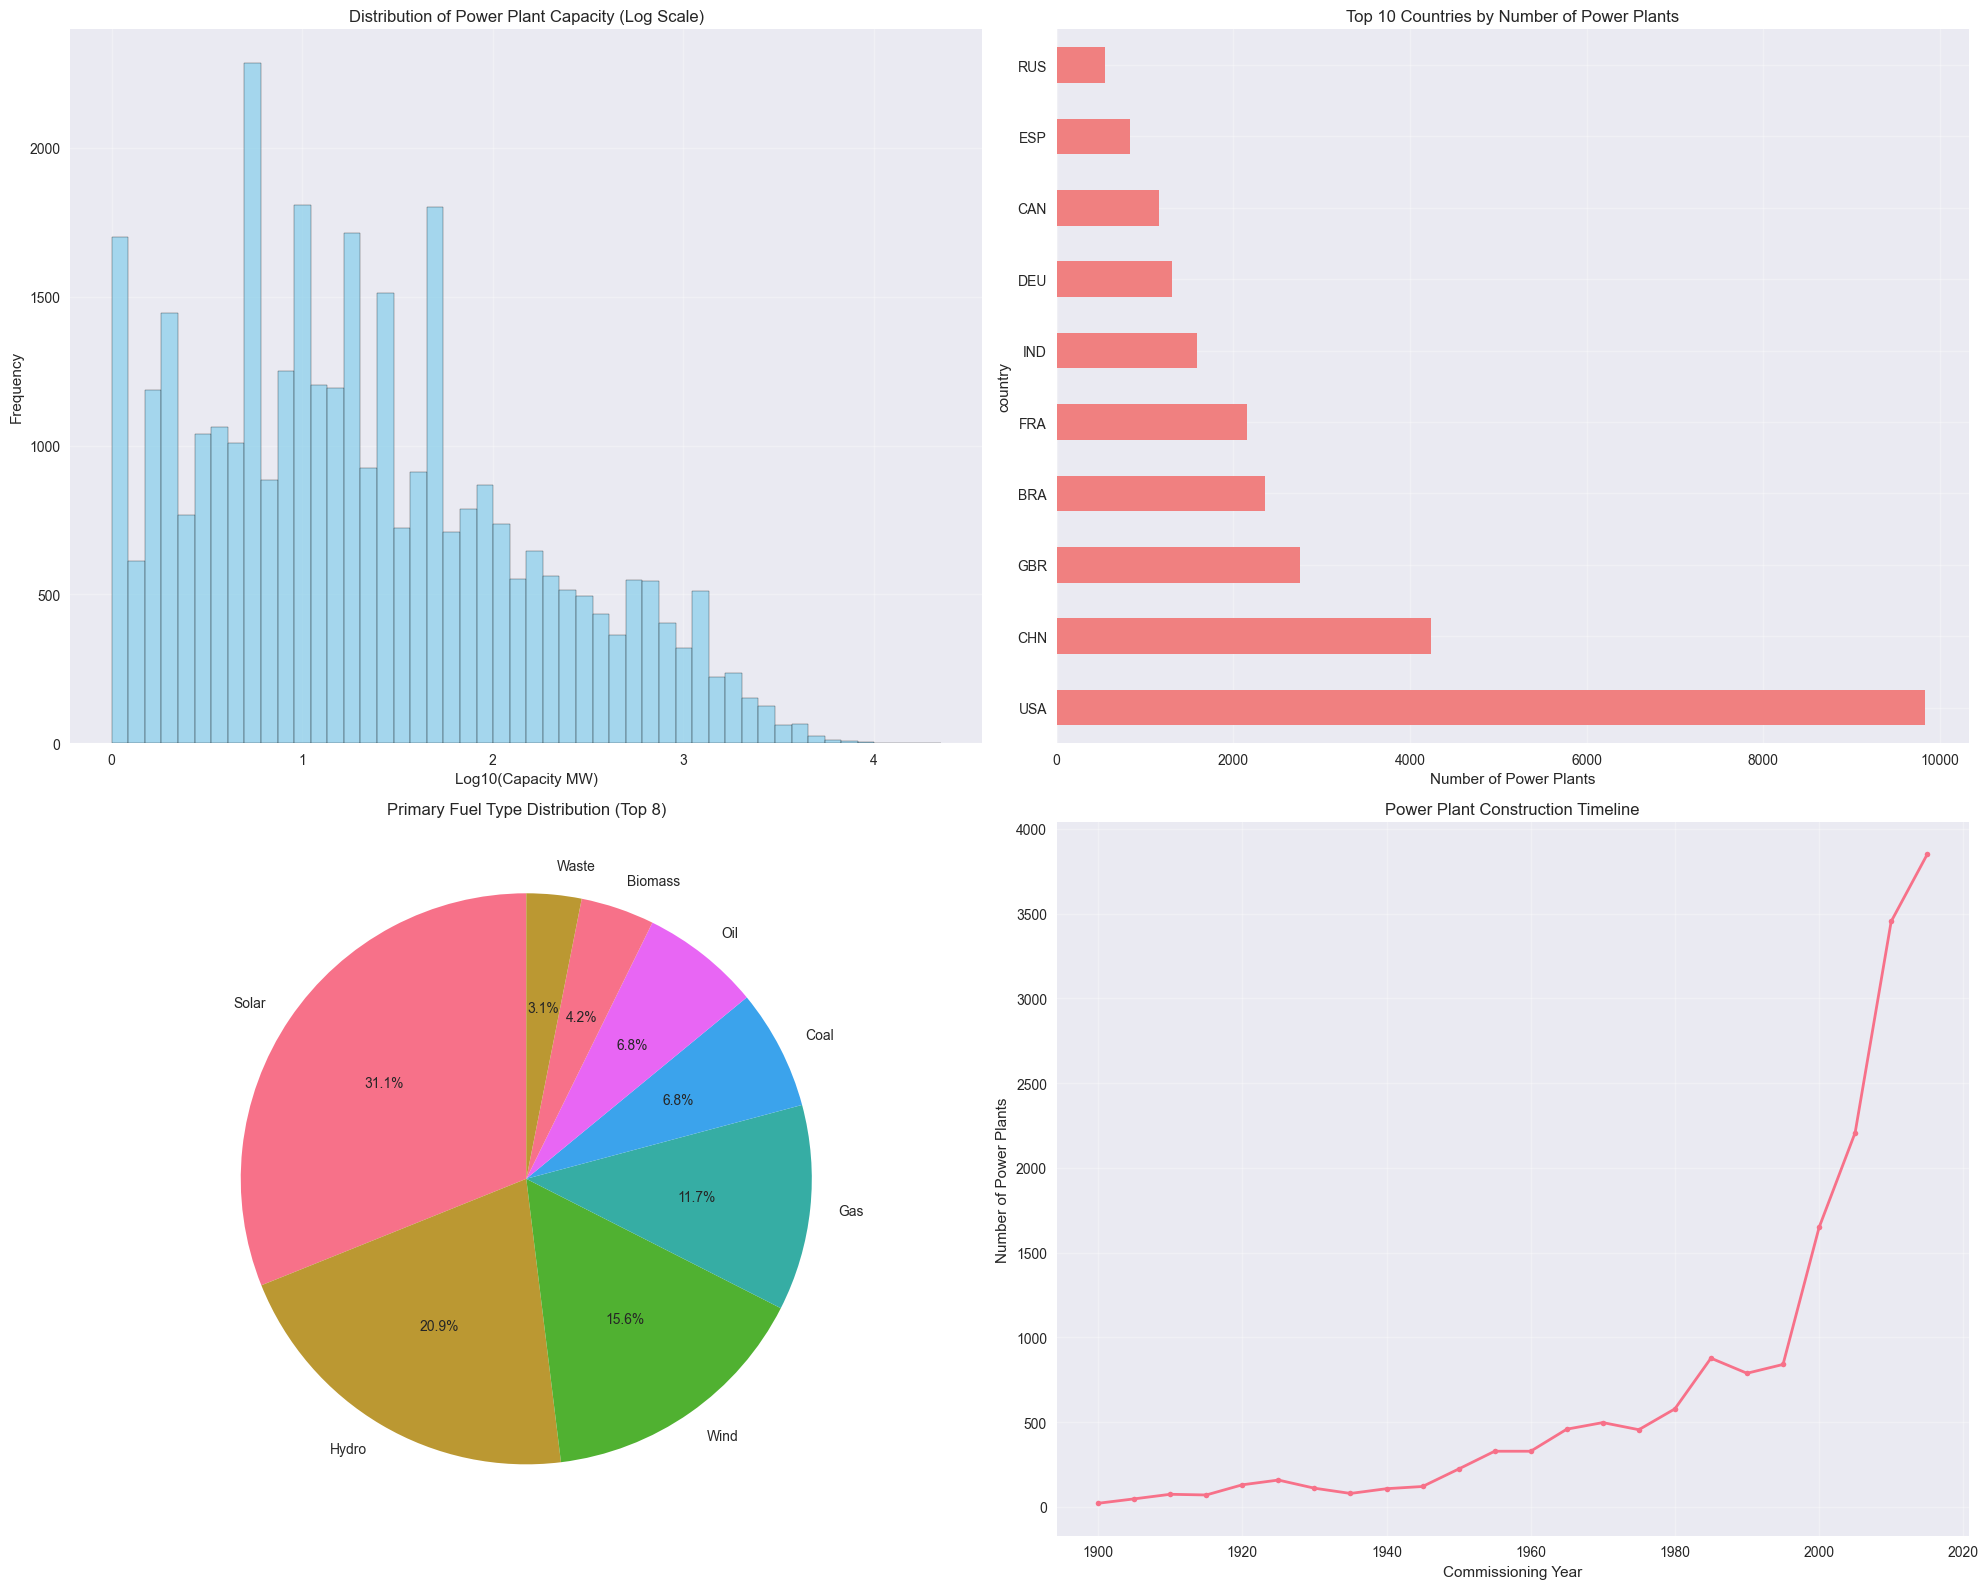


4. CORRELATION ANALYSIS USING NUMPY
--------------------------------------------------
Correlation Matrix:
                    capacity_mw  latitude  longitude  commissioning_year
capacity_mw               1.000     0.009      0.340              -0.014
latitude                  0.009     1.000     -0.103              -0.152
longitude                 0.340    -0.103      1.000              -0.024
commissioning_year       -0.014    -0.152     -0.024               1.000


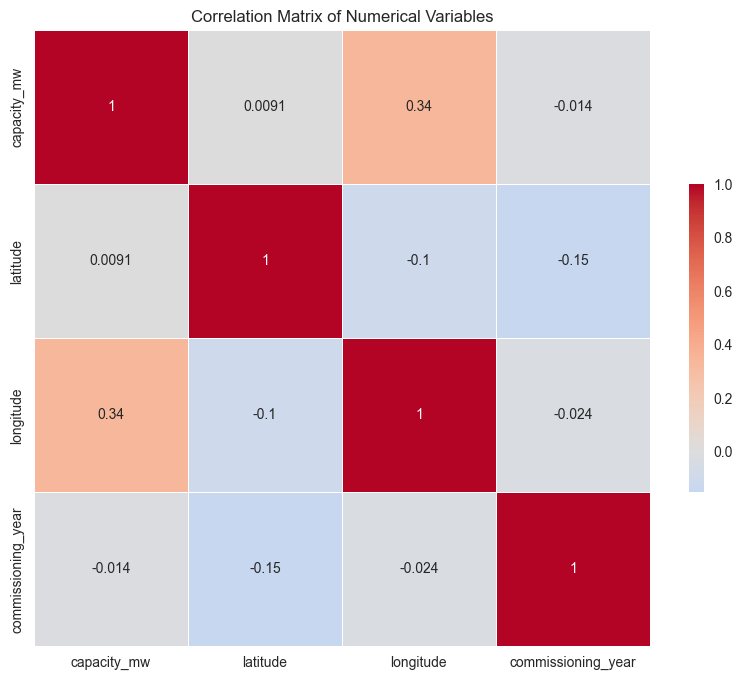

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# 1. Capacity distribution (log scale)
axes[0, 0].hist(np.log10(df_clean['capacity_mw'].dropna()), bins=50, 
                alpha=0.7, color='skyblue', edgecolor='black')
axes[0, 0].set_xlabel('Log10(Capacity MW)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Power Plant Capacity (Log Scale)')
axes[0, 0].grid(True, alpha=0.3)

# 2. Top countries by count
country_counts.head(10).plot(kind='barh', ax=axes[0, 1], color='lightcoral')
axes[0, 1].set_xlabel('Number of Power Plants')
axes[0, 1].set_title('Top 10 Countries by Number of Power Plants')
axes[0, 1].grid(True, alpha=0.3)

# 3. Fuel type distribution
fuel_stats.head(8).plot(kind='pie', ax=axes[1, 0], autopct='%1.1f%%', startangle=90)
axes[1, 0].set_ylabel('')
axes[1, 0].set_title('Primary Fuel Type Distribution (Top 8)')

# 4. Commissioning year trend
commissioning_years = df_clean['commissioning_year'].dropna()
year_range = np.arange(1900, 2025, 5)
year_counts, _ = np.histogram(commissioning_years, bins=year_range)

axes[1, 1].plot(year_range[:-1], year_counts, marker='o', linewidth=2, markersize=4)
axes[1, 1].set_xlabel('Commissioning Year')
axes[1, 1].set_ylabel('Number of Power Plants')
axes[1, 1].set_title('Power Plant Construction Timeline')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Advanced NumPy correlation analysis
print(f"\n4. CORRELATION ANALYSIS USING NUMPY")
print("-"*50)

# Select numerical columns for correlation
corr_cols = ['capacity_mw', 'latitude', 'longitude', 'commissioning_year']
corr_data = df_clean[corr_cols].dropna()

# Calculate correlation matrix using NumPy
corr_matrix = np.corrcoef(corr_data.T)

# Create correlation DataFrame
corr_df = pd.DataFrame(corr_matrix, index=corr_cols, columns=corr_cols)
print("Correlation Matrix:")
print(corr_df.round(3))

# Visualize correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_df, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": .5})
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

## Task 3: Statistical Analysis



STATISTICAL ANALYSIS BY FUEL TYPE
Major fuel types for analysis: ['Solar', 'Hydro', 'Wind', 'Gas', 'Coal', 'Oil', 'Biomass', 'Waste']

Comprehensive Statistical Summary by Fuel Type:
----------------------------------------------------------------------
           count     mean  median      std  skewness  kurtosis
Solar    10665.0   17.657    5.80   41.939    10.686   186.620
Hydro     7156.0  147.172   20.00  549.809    17.066   502.193
Wind      5344.0   49.224   27.00  106.138    34.039  1852.305
Gas       3998.0  373.449  147.50  560.934     3.900    28.820
Coal      2330.0  843.580  600.00  888.187     2.006     5.504
Oil       2320.0  112.879    9.00  392.009     7.395    75.591
Biomass   1430.0   23.973    9.45   39.462     4.426    33.036
Waste     1068.0   13.810    4.80   20.583     2.774     9.230

Advanced Statistics:
------------------------------
           range       iqr     cv     sem
Solar     1020.0    15.400  2.375   0.406
Hydro    22499.0    88.205  3.736   6.499


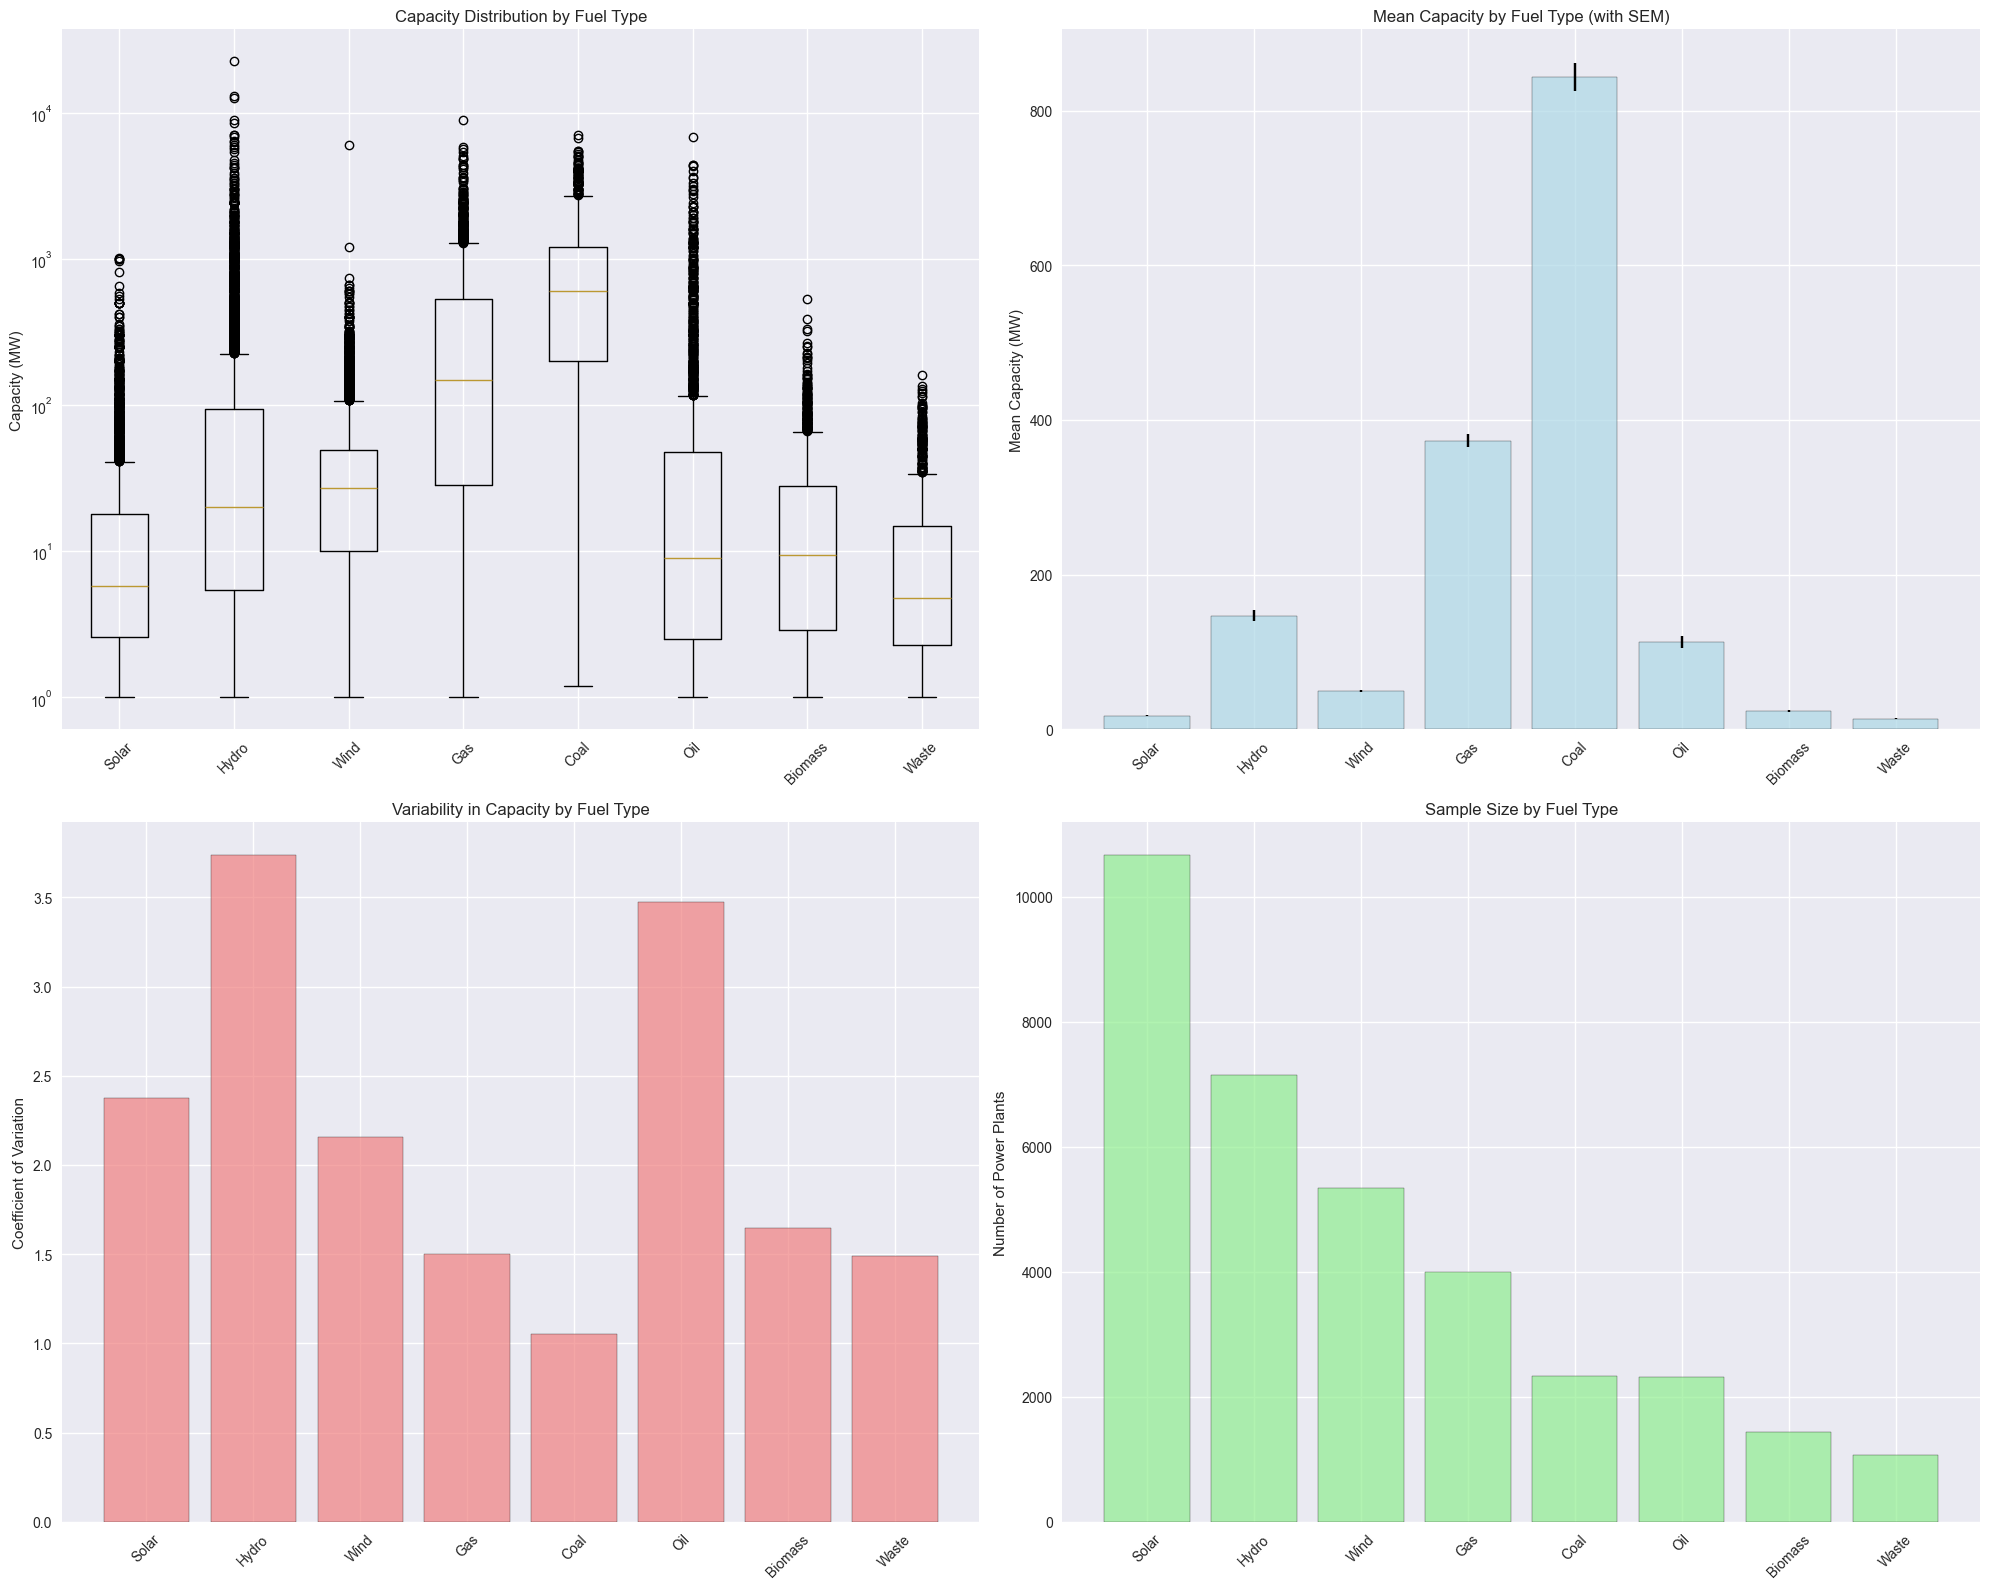

In [9]:
# Statistical Analysis of Power Output by Fuel Type
print("STATISTICAL ANALYSIS BY FUEL TYPE")
print("="*70)

major_fuels = df_clean['primary_fuel'].value_counts().head(8).index.tolist()
print(f"Major fuel types for analysis: {major_fuels}")

fuel_statistics = {}

for fuel in major_fuels:
    fuel_data = df_clean[df_clean['primary_fuel'] == fuel]['capacity_mw'].dropna().values
    
    if len(fuel_data) > 0:
        fuel_statistics[fuel] = {
            'count': len(fuel_data),
            'mean': np.mean(fuel_data),
            'median': np.median(fuel_data),
            'std': np.std(fuel_data, ddof=1),  # Sample standard deviation
            'var': np.var(fuel_data, ddof=1),   # Sample variance
            'min': np.min(fuel_data),
            'max': np.max(fuel_data),
            'range': np.ptp(fuel_data),
            'q25': np.percentile(fuel_data, 25),
            'q75': np.percentile(fuel_data, 75),
            'iqr': np.percentile(fuel_data, 75) - np.percentile(fuel_data, 25),
            'skewness': stats.skew(fuel_data),
            'kurtosis': stats.kurtosis(fuel_data),
            'sem': stats.sem(fuel_data),  # Standard error of mean
            'cv': np.std(fuel_data, ddof=1) / np.mean(fuel_data)  # Coefficient of variation
        }

# Convert to DataFrame for better visualization
fuel_stats_df = pd.DataFrame(fuel_statistics).T
fuel_stats_df = fuel_stats_df.round(3)

print("\nComprehensive Statistical Summary by Fuel Type:")
print("-"*70)
print(fuel_stats_df[['count', 'mean', 'median', 'std', 'skewness', 'kurtosis']])

print(f"\nAdvanced Statistics:")
print("-"*30)
print(fuel_stats_df[['range', 'iqr', 'cv', 'sem']])

# Visualize distributions
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# 1. Box plot comparison
fuel_capacity_lists = [df_clean[df_clean['primary_fuel'] == fuel]['capacity_mw'].dropna().values 
                      for fuel in major_fuels]

axes[0, 0].boxplot(fuel_capacity_lists, labels=major_fuels)
axes[0, 0].set_ylabel('Capacity (MW)')
axes[0, 0].set_title('Capacity Distribution by Fuel Type')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].set_yscale('log')  # Log scale for better visualization

# 2. Mean capacity comparison
means = [fuel_statistics[fuel]['mean'] for fuel in major_fuels]
std_errs = [fuel_statistics[fuel]['sem'] for fuel in major_fuels]

bars = axes[0, 1].bar(major_fuels, means, yerr=std_errs, capsize=5, 
                      color='lightblue', edgecolor='black', alpha=0.7)
axes[0, 1].set_ylabel('Mean Capacity (MW)')
axes[0, 1].set_title('Mean Capacity by Fuel Type (with SEM)')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Coefficient of variation comparison
cvs = [fuel_statistics[fuel]['cv'] for fuel in major_fuels]
axes[1, 0].bar(major_fuels, cvs, color='lightcoral', edgecolor='black', alpha=0.7)
axes[1, 0].set_ylabel('Coefficient of Variation')
axes[1, 0].set_title('Variability in Capacity by Fuel Type')
axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Sample size comparison
counts = [fuel_statistics[fuel]['count'] for fuel in major_fuels]
axes[1, 1].bar(major_fuels, counts, color='lightgreen', edgecolor='black', alpha=0.7)
axes[1, 1].set_ylabel('Number of Power Plants')
axes[1, 1].set_title('Sample Size by Fuel Type')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [10]:
# Hypothesis Testing: Do fuel types have significantly different mean capacities?
print("HYPOTHESIS TESTING")
print("="*50)

# Select top 4 fuel types for detailed comparison
top_fuels = major_fuels[:4]
print(f"Comparing fuel types: {top_fuels}")

# Extract capacity data for each fuel type
fuel_groups = {}
for fuel in top_fuels:
    fuel_groups[fuel] = df_clean[df_clean['primary_fuel'] == fuel]['capacity_mw'].dropna().values

# Perform pairwise t-tests
print(f"\nPairwise T-Tests (Two-sample, independent):")
print("-"*50)

test_results = []

for i, fuel1 in enumerate(top_fuels):
    for j, fuel2 in enumerate(top_fuels):
        if i < j:  # Avoid duplicate comparisons
            group1 = fuel_groups[fuel1]
            group2 = fuel_groups[fuel2]
            
            # Perform independent t-test
            t_stat, p_value = ttest_ind(group1, group2, equal_var=False)  # Welch's t-test
            
            # Effect size (Cohen's d)
            pooled_std = np.sqrt(((len(group1)-1)*np.var(group1, ddof=1) + 
                                 (len(group2)-1)*np.var(group2, ddof=1)) / 
                                (len(group1) + len(group2) - 2))
            cohens_d = (np.mean(group1) - np.mean(group2)) / pooled_std
            
            test_results.append({
                'Fuel_1': fuel1,
                'Fuel_2': fuel2,
                'T_Statistic': t_stat,
                'P_Value': p_value,
                'Significant': p_value < 0.05,
                'Cohens_D': cohens_d,
                'Effect_Size': 'Small' if abs(cohens_d) < 0.5 else 'Medium' if abs(cohens_d) < 0.8 else 'Large'
            })

# Create results DataFrame
test_results_df = pd.DataFrame(test_results)
test_results_df = test_results_df.round(4)

print(test_results_df)

# One-way ANOVA test
print(f"\nOne-Way ANOVA Test:")
print("-"*30)

# Prepare data for ANOVA
anova_groups = [fuel_groups[fuel] for fuel in top_fuels]

# Perform ANOVA
f_stat, p_value_anova = stats.f_oneway(*anova_groups)

print(f"F-statistic: {f_stat:.4f}")
print(f"P-value: {p_value_anova:.6f}")
print(f"Significant difference: {'Yes' if p_value_anova < 0.05 else 'No'}")

# Effect size for ANOVA (eta-squared)
# Calculate total sum of squares and within-group sum of squares
all_data = np.concatenate(anova_groups)
grand_mean = np.mean(all_data)
total_ss = np.sum((all_data - grand_mean)**2)

within_ss = sum(np.sum((group - np.mean(group))**2) for group in anova_groups)
between_ss = total_ss - within_ss

eta_squared = between_ss / total_ss
print(f"Eta-squared (effect size): {eta_squared:.4f}")

# Statistical power analysis using NumPy
print(f"\nStatistical Power Analysis:")
print("-"*30)

for i, (fuel1, fuel2) in enumerate([(top_fuels[0], top_fuels[1]), 
                                   (top_fuels[0], top_fuels[2])]):
    group1 = fuel_groups[fuel1]
    group2 = fuel_groups[fuel2]
    
    # Calculate statistical power components
    alpha = 0.05
    n1, n2 = len(group1), len(group2)
    
    # Effect size
    pooled_std = np.sqrt(((n1-1)*np.var(group1, ddof=1) + 
                         (n2-1)*np.var(group2, ddof=1)) / (n1 + n2 - 2))
    effect_size = abs(np.mean(group1) - np.mean(group2)) / pooled_std
    
    # Standard error
    se = pooled_std * np.sqrt(1/n1 + 1/n2)
    
    # Critical t-value
    df = n1 + n2 - 2
    t_critical = stats.t.ppf(1 - alpha/2, df)
    
    print(f"{fuel1} vs {fuel2}:")
    print(f"  Effect size (Cohen's d): {effect_size:.3f}")
    print(f"  Sample sizes: {n1}, {n2}")
    print(f"  Standard error: {se:.3f}")
    print(f"  Degrees of freedom: {df}")
    print()

HYPOTHESIS TESTING
Comparing fuel types: ['Solar', 'Hydro', 'Wind', 'Gas']

Pairwise T-Tests (Two-sample, independent):
--------------------------------------------------
  Fuel_1 Fuel_2  T_Statistic  P_Value  Significant  Cohens_D Effect_Size
0  Solar  Hydro     -19.8882      0.0         True   -0.3701       Small
1  Solar   Wind     -20.9382      0.0         True   -0.4495       Small
2  Solar    Gas     -40.0637      0.0         True   -1.2058       Large
3  Hydro   Wind      14.7076      0.0         True    0.2322       Small
4  Hydro    Gas     -20.5755      0.0         True   -0.4086       Small
5   Wind    Gas     -36.0675      0.0         True   -0.8632       Large

One-Way ANOVA Test:
------------------------------
F-statistic: 1029.7371
P-value: 0.000000
Significant difference: Yes
Eta-squared (effect size): 0.1021

Statistical Power Analysis:
------------------------------
Solar vs Hydro:
  Effect size (Cohen's d): 0.370
  Sample sizes: 10665, 7156
  Standard error: 5.347
  

## Task 4: Time Series Analysis



TIME SERIES ANALYSIS
Valid commissioning year data: 17445 plants
Year range: 1900.0 - 2020.0

1. OVERALL POWER PLANT CONSTRUCTION TRENDS
--------------------------------------------------
Linear trend analysis (1950-2024):
  Slope: 6.622 plants/year
  R-squared: 0.407
  P-value: 0.000000
  Trend: Increasing



Decade Analysis:
  Decade  Plant_Count  Total_Capacity  Mean_Capacity  Median_Capacity
0  1950s          551        78226.41         141.97            40.00
1  1960s          786       201337.30         256.15            64.00
2  1970s          952       423164.90         444.50           110.00
3  1980s         1455       428325.82         294.38            31.10
4  1990s         1628       396791.59         243.73            40.92
5  2000s         3855      1163571.99         301.83            40.00
6  2010s         7152      1057646.67         147.88             7.40


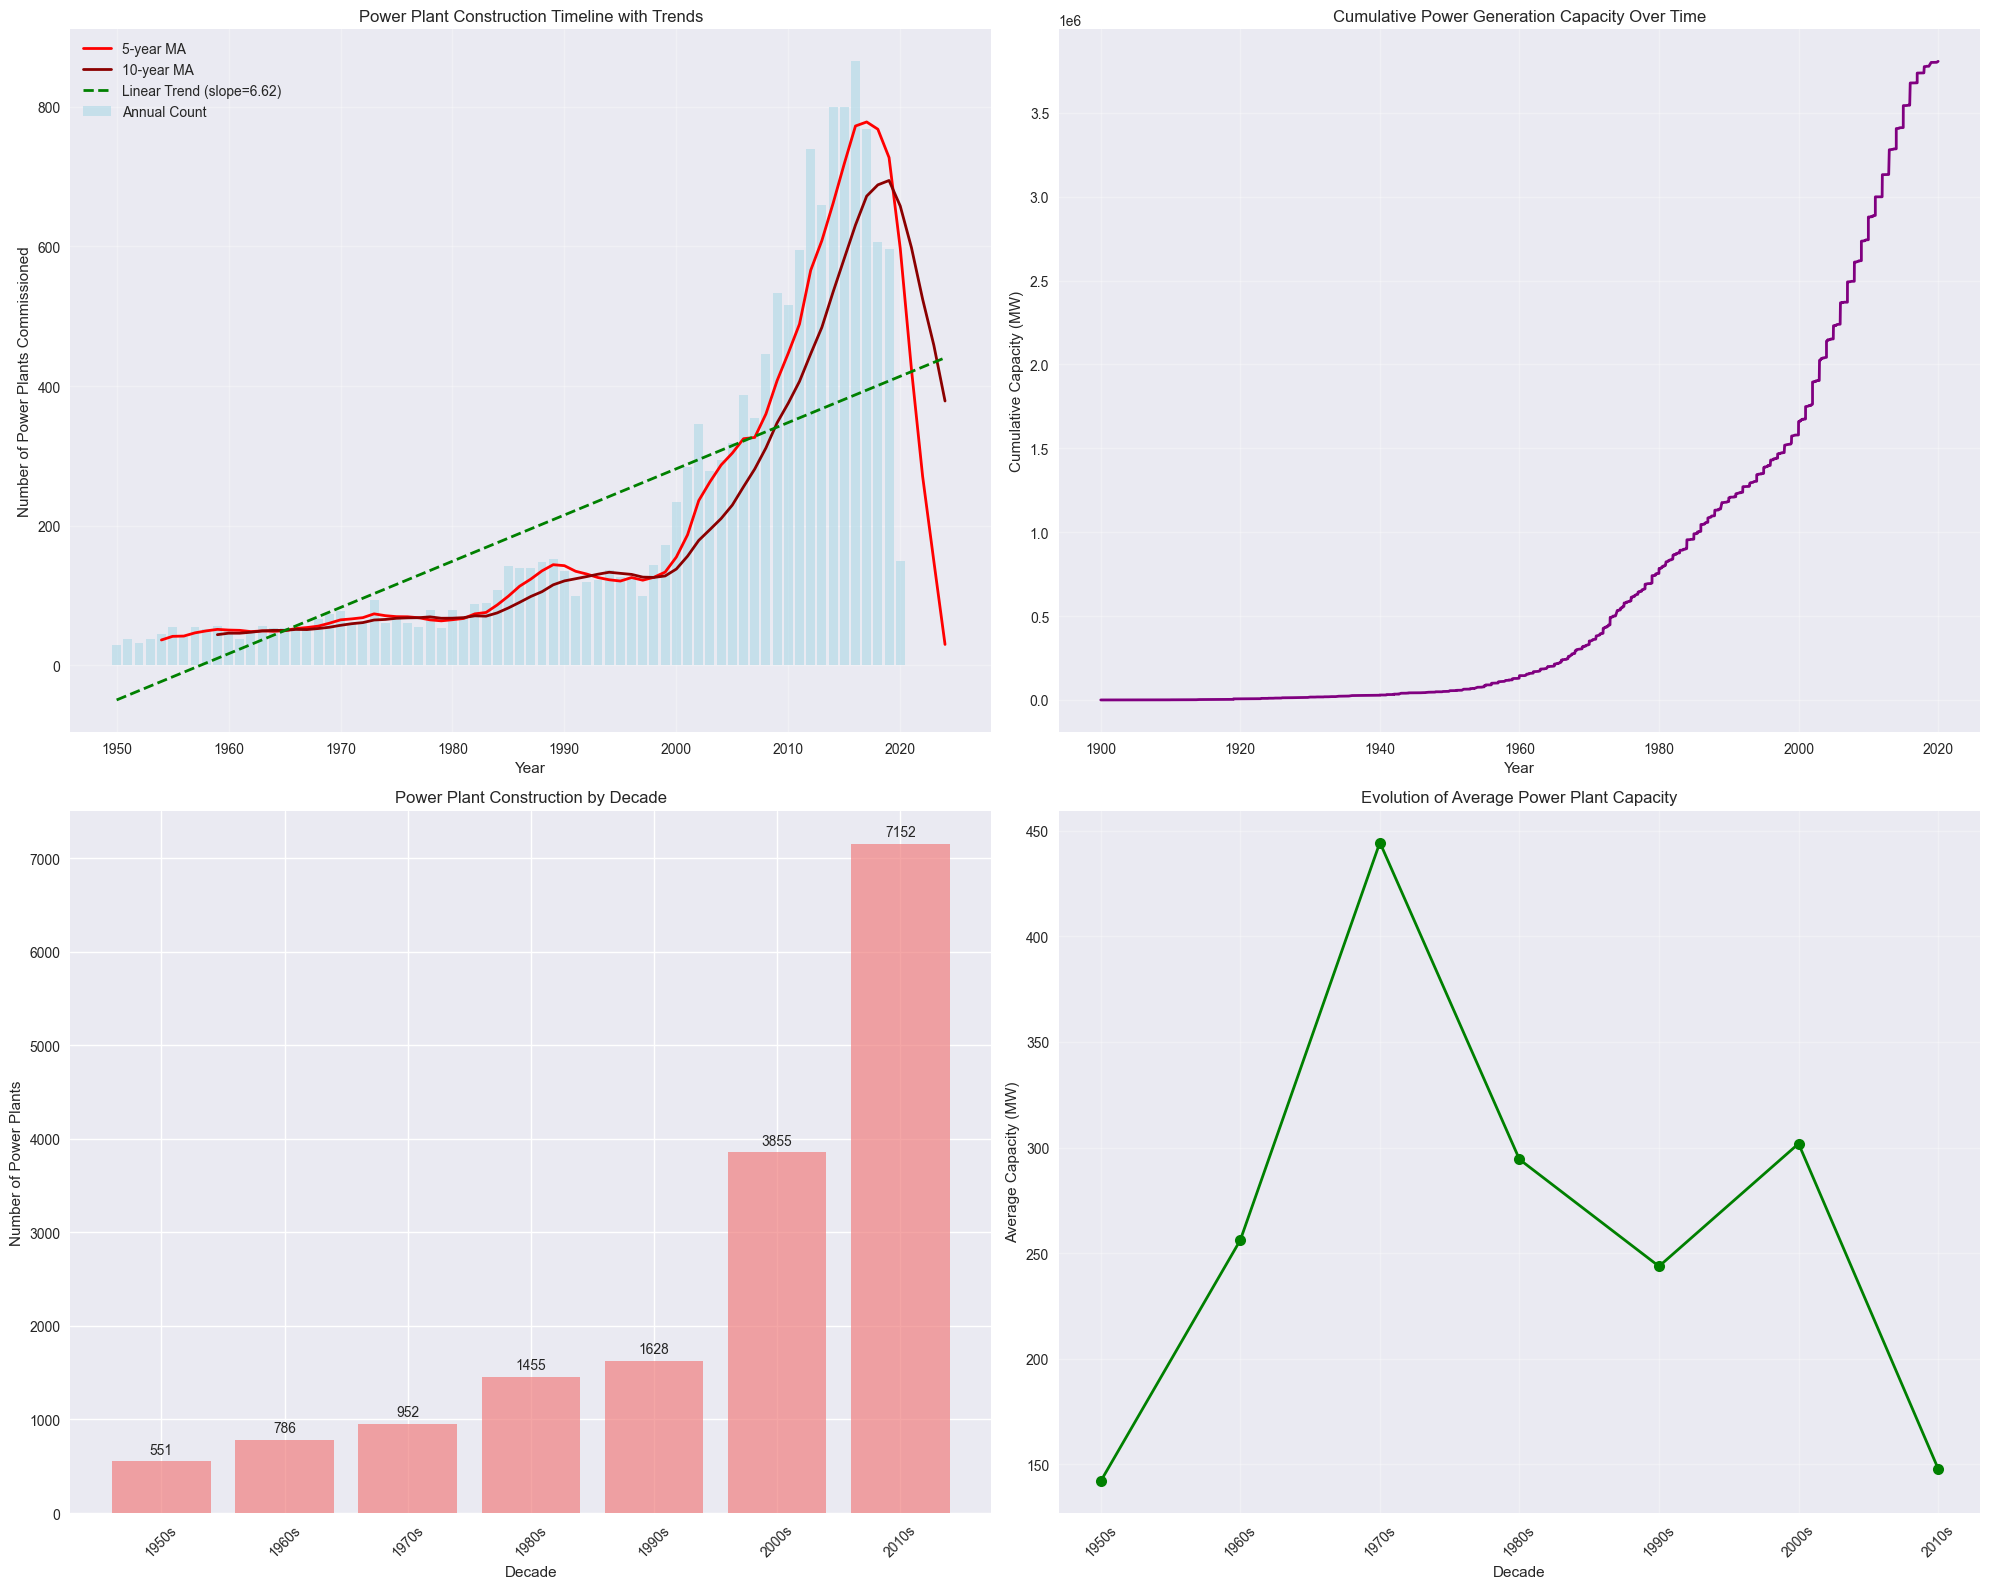

In [11]:
# Time Series Analysis using NumPy and Pandas
print("TIME SERIES ANALYSIS")
print("="*50)

# Clean commissioning year data
valid_years = df_clean[(df_clean['commissioning_year'] >= 1900) & 
                      (df_clean['commissioning_year'] <= 2024)].copy()

print(f"Valid commissioning year data: {len(valid_years)} plants")
print(f"Year range: {valid_years['commissioning_year'].min()} - {valid_years['commissioning_year'].max()}")

# Create time series analysis
year_range = np.arange(1950, 2025, 1)  # Focus on modern era

# 1. Overall trend analysis
print(f"\n1. OVERALL POWER PLANT CONSTRUCTION TRENDS")
print("-"*50)

# Count plants by year
yearly_counts = valid_years['commissioning_year'].value_counts().sort_index()

# Create complete time series with zeros for missing years
complete_yearly_counts = pd.Series(index=year_range, dtype=int)
complete_yearly_counts = complete_yearly_counts.fillna(0)

for year, count in yearly_counts.items():
    if year in complete_yearly_counts.index:
        complete_yearly_counts[year] = count

# Convert to NumPy arrays for analysis
years = complete_yearly_counts.index.values
counts = complete_yearly_counts.values

# Calculate moving averages using NumPy
window_5 = 5
window_10 = 10

# 5-year moving average
ma_5 = np.convolve(counts, np.ones(window_5)/window_5, mode='valid')
ma_5_years = years[window_5-1:]

# 10-year moving average
ma_10 = np.convolve(counts, np.ones(window_10)/window_10, mode='valid')
ma_10_years = years[window_10-1:]

# Trend analysis using linear regression
from scipy.stats import linregress

# Overall trend (1950-2024)
slope, intercept, r_value, p_value, std_err = linregress(years, counts)

print(f"Linear trend analysis (1950-2024):")
print(f"  Slope: {slope:.3f} plants/year")
print(f"  R-squared: {r_value**2:.3f}")
print(f"  P-value: {p_value:.6f}")
print(f"  Trend: {'Increasing' if slope > 0 else 'Decreasing'}")

# Decade analysis
decades = np.arange(1950, 2030, 10)
decade_stats = []

for i in range(len(decades)-1):
    decade_start = decades[i]
    decade_end = decades[i+1]
    
    decade_data = valid_years[
        (valid_years['commissioning_year'] >= decade_start) & 
        (valid_years['commissioning_year'] < decade_end)
    ]
    
    decade_stats.append({
        'Decade': f"{decade_start}s",
        'Plant_Count': len(decade_data),
        'Total_Capacity': decade_data['capacity_mw'].sum(),
        'Mean_Capacity': decade_data['capacity_mw'].mean(),
        'Median_Capacity': decade_data['capacity_mw'].median()
    })

decade_df = pd.DataFrame(decade_stats)
print(f"\nDecade Analysis:")
print(decade_df.round(2))

# Visualize overall trends
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# 1. Raw counts with moving averages
axes[0, 0].bar(years, counts, alpha=0.6, color='lightblue', label='Annual Count')
axes[0, 0].plot(ma_5_years, ma_5, color='red', linewidth=2, label='5-year MA')
axes[0, 0].plot(ma_10_years, ma_10, color='darkred', linewidth=2, label='10-year MA')
axes[0, 0].plot(years, slope * years + intercept, '--', color='green', linewidth=2, 
                label=f'Linear Trend (slope={slope:.2f})')
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Number of Power Plants Commissioned')
axes[0, 0].set_title('Power Plant Construction Timeline with Trends')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Cumulative capacity over time
cumulative_capacity = valid_years.groupby('commissioning_year')['capacity_mw'].sum().cumsum()
axes[0, 1].plot(cumulative_capacity.index, cumulative_capacity.values, 
                linewidth=2, color='purple')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Cumulative Capacity (MW)')
axes[0, 1].set_title('Cumulative Power Generation Capacity Over Time')
axes[0, 1].grid(True, alpha=0.3)

# 3. Decade comparison
decade_counts = [stats['Plant_Count'] for stats in decade_stats]
decade_labels = [stats['Decade'] for stats in decade_stats]
bars = axes[1, 0].bar(decade_labels, decade_counts, color='lightcoral', alpha=0.7)
axes[1, 0].set_xlabel('Decade')
axes[1, 0].set_ylabel('Number of Power Plants')
axes[1, 0].set_title('Power Plant Construction by Decade')
axes[1, 0].tick_params(axis='x', rotation=45)

# Add value labels on bars
for bar, count in zip(bars, decade_counts):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                    f'{count}', ha='center', va='bottom')

# 4. Average capacity trend by decade
decade_avg_capacity = [stats['Mean_Capacity'] for stats in decade_stats]
axes[1, 1].plot(decade_labels, decade_avg_capacity, marker='o', linewidth=2, 
                markersize=8, color='green')
axes[1, 1].set_xlabel('Decade')
axes[1, 1].set_ylabel('Average Capacity (MW)')
axes[1, 1].set_title('Evolution of Average Power Plant Capacity')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


2. FUEL MIX EVOLUTION ANALYSIS
--------------------------------------------------
Fuel Mix Evolution by Period (% of new plants):
      Period  Total_Plants  Coal_Pct  Gas_Pct  Hydro_Pct  Nuclear_Pct  \
0  1950-1970          1337     11.29    16.31      59.24         0.07   
1  1970-1990          2407     15.79    20.77      34.03         3.41   
2  1990-2010          5483     14.32    25.64      15.23         0.20   
3  2010-2024          7302      7.64     7.81       7.16         0.05   

   Oil_Pct  Solar_Pct  Wind_Pct  Other_Pct  
0     9.42       0.00      0.00       3.67  
1    14.29       0.21      1.16      10.34  
2    13.28       1.15     17.36      12.82  
3     5.42      47.00     17.45       7.47  

3. RENEWABLE ENERGY GROWTH ANALYSIS
--------------------------------------------------
Renewable Energy Growth Analysis (2000-2024):
  Exponential growth rate: 8.35% per year
  R-squared: 0.693
  Statistical significance: 0.000003
  Doubling time: 8.6 years


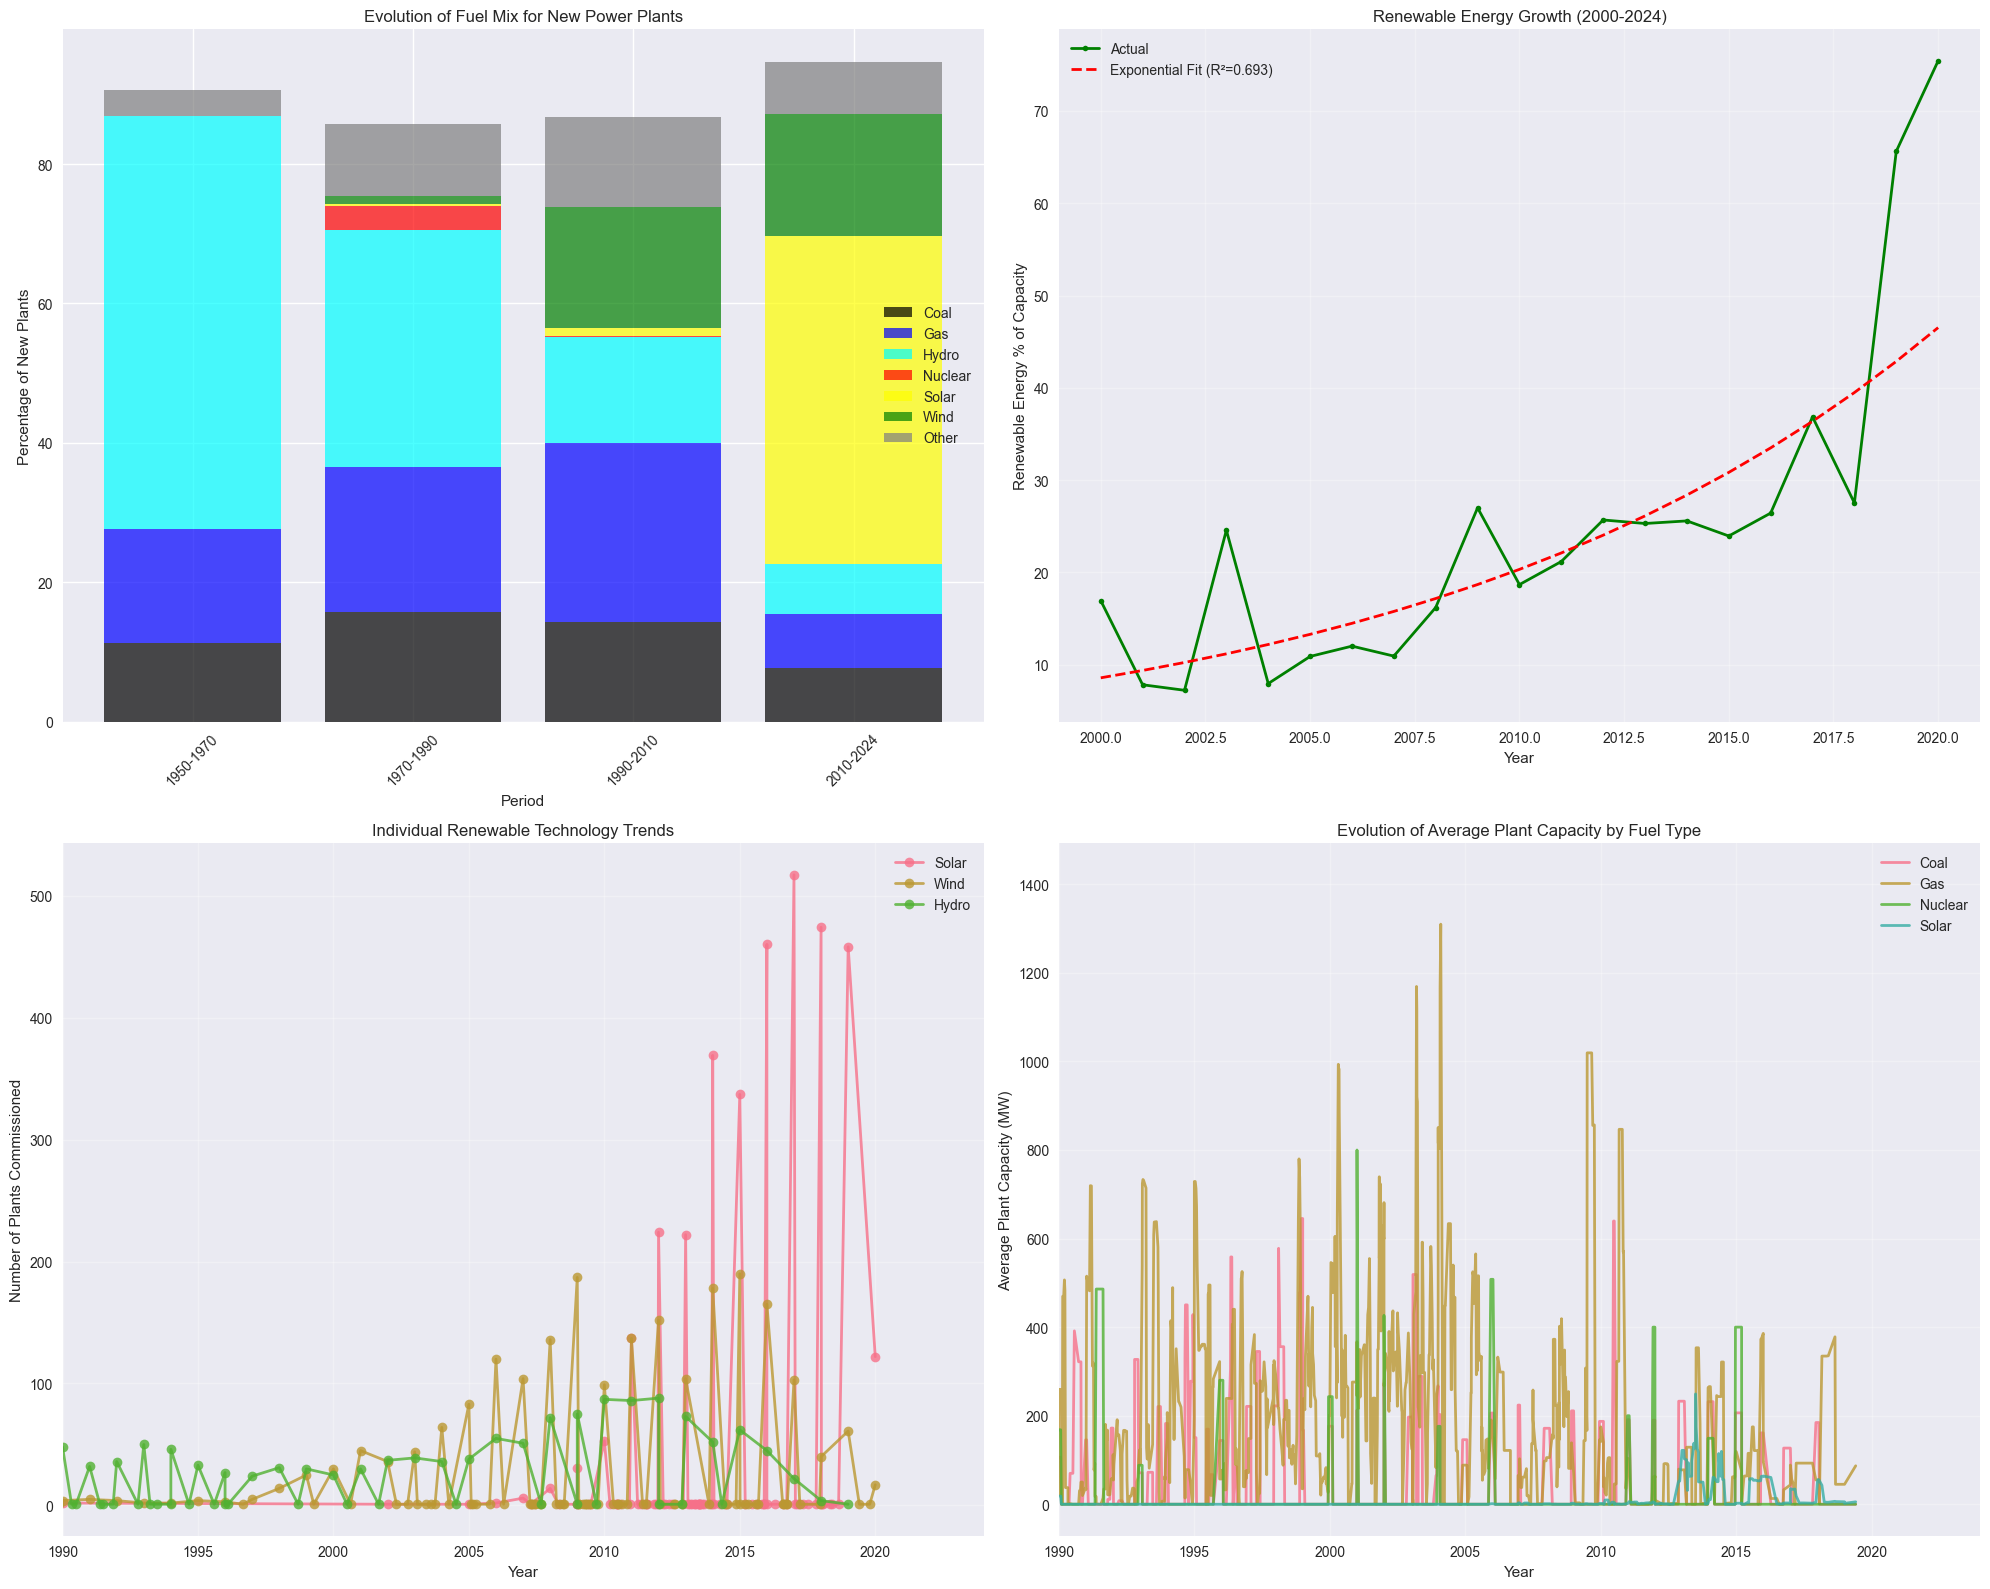

In [12]:
print(f"\n2. FUEL MIX EVOLUTION ANALYSIS")
print("-"*50)

fuel_evolution_periods = [
    (1950, 1970, "1950-1970"),
    (1970, 1990, "1970-1990"),
    (1990, 2010, "1990-2010"),
    (2010, 2024, "2010-2024")
]

fuel_evolution_data = []

for start_year, end_year, period_label in fuel_evolution_periods:
    period_data = valid_years[
        (valid_years['commissioning_year'] >= start_year) & 
        (valid_years['commissioning_year'] < end_year)
    ]
    
    #  fuel type percentages
    fuel_counts = period_data['primary_fuel'].value_counts()
    fuel_percentages = (fuel_counts / fuel_counts.sum() * 100).round(2)
    
    period_summary = {
        'Period': period_label,
        'Total_Plants': len(period_data),
        'Coal_Pct': fuel_percentages.get('Coal', 0),
        'Gas_Pct': fuel_percentages.get('Gas', 0),
        'Hydro_Pct': fuel_percentages.get('Hydro', 0),
        'Nuclear_Pct': fuel_percentages.get('Nuclear', 0),
        'Oil_Pct': fuel_percentages.get('Oil', 0),
        'Solar_Pct': fuel_percentages.get('Solar', 0),
        'Wind_Pct': fuel_percentages.get('Wind', 0),
        'Other_Pct': 100 - sum([fuel_percentages.get(fuel, 0) 
                               for fuel in ['Coal', 'Gas', 'Hydro', 'Nuclear', 'Oil', 'Solar', 'Wind']])
    }
    
    fuel_evolution_data.append(period_summary)

fuel_evolution_df = pd.DataFrame(fuel_evolution_data)
print("Fuel Mix Evolution by Period (% of new plants):")
print(fuel_evolution_df)

# Advanced time series analysis for renewable energy growth
print(f"\n3. RENEWABLE ENERGY GROWTH ANALYSIS")
print("-"*50)

renewable_fuels = ['Solar', 'Wind', 'Hydro', 'Geothermal', 'Biomass', 'Wave and Tidal']

# Yearly renewable energy analysis
yearly_renewable_analysis = []

for year in range(1990, 2025):
    year_data = valid_years[valid_years['commissioning_year'] == year]
    
    if len(year_data) > 0:
        total_plants = len(year_data)
        renewable_plants = len(year_data[year_data['primary_fuel'].isin(renewable_fuels)])
        renewable_capacity = year_data[year_data['primary_fuel'].isin(renewable_fuels)]['capacity_mw'].sum()
        total_capacity = year_data['capacity_mw'].sum()
        
        yearly_renewable_analysis.append({
            'Year': year,
            'Total_Plants': total_plants,
            'Renewable_Plants': renewable_plants,
            'Renewable_Pct_Count': (renewable_plants / total_plants * 100) if total_plants > 0 else 0,
            'Total_Capacity': total_capacity,
            'Renewable_Capacity': renewable_capacity,
            'Renewable_Pct_Capacity': (renewable_capacity / total_capacity * 100) if total_capacity > 0 else 0
        })

renewable_df = pd.DataFrame(yearly_renewable_analysis)

# Calculate growth rates using NumPy
renewable_pct_capacity = renewable_df['Renewable_Pct_Capacity'].values
years_analysis = renewable_df['Year'].values

# Exponential growth analysis for renewables (post-2000)
post_2000_mask = years_analysis >= 2000
post_2000_years = years_analysis[post_2000_mask]
post_2000_renewable_pct = renewable_pct_capacity[post_2000_mask]

# Fit exponential curve: y = a * exp(b * x)
# Using log transformation: log(y+1) = log(a) + b*x
log_renewable = np.log(post_2000_renewable_pct + 1)  # +1 to handle zeros
slope_exp, intercept_exp, r_exp, p_exp, se_exp = linregress(post_2000_years, log_renewable)

print(f"Renewable Energy Growth Analysis (2000-2024):")
print(f"  Exponential growth rate: {(np.exp(slope_exp) - 1) * 100:.2f}% per year")
print(f"  R-squared: {r_exp**2:.3f}")
print(f"  Statistical significance: {p_exp:.6f}")

# Calculate doubling time
doubling_time = np.log(2) / slope_exp if slope_exp > 0 else float('inf')
print(f"  Doubling time: {doubling_time:.1f} years")

# Visualize fuel mix evolution
fig, axes = plt.subplots(2, 2, figsize=(20, 16))

# 1. Fuel mix evolution stacked bar chart
periods = fuel_evolution_df['Period']
fuel_types = ['Coal_Pct', 'Gas_Pct', 'Hydro_Pct', 'Nuclear_Pct', 'Solar_Pct', 'Wind_Pct', 'Other_Pct']
colors = ['black', 'blue', 'cyan', 'red', 'yellow', 'green', 'gray']

bottom = np.zeros(len(periods))
for fuel, color in zip(fuel_types, colors):
    values = fuel_evolution_df[fuel].values
    axes[0, 0].bar(periods, values, bottom=bottom, label=fuel.replace('_Pct', ''), 
                   color=color, alpha=0.7)
    bottom += values

axes[0, 0].set_xlabel('Period')
axes[0, 0].set_ylabel('Percentage of New Plants')
axes[0, 0].set_title('Evolution of Fuel Mix for New Power Plants')
axes[0, 0].legend()
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Renewable energy growth
renewable_subset = renewable_df[renewable_df['Year'] >= 2000]
axes[0, 1].plot(renewable_subset['Year'], renewable_subset['Renewable_Pct_Capacity'], 
                marker='o', linewidth=2, markersize=4, color='green', label='Actual')

# Add exponential fit
exp_fit = np.exp(intercept_exp + slope_exp * post_2000_years) - 1
axes[0, 1].plot(post_2000_years, exp_fit, '--', color='red', linewidth=2, 
                label=f'Exponential Fit (R²={r_exp**2:.3f})')

axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Renewable Energy % of Capacity')
axes[0, 1].set_title('Renewable Energy Growth (2000-2024)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Individual renewable technology trends
renewable_tech_trends = valid_years[valid_years['primary_fuel'].isin(['Solar', 'Wind', 'Hydro'])]
for tech in ['Solar', 'Wind', 'Hydro']:
    tech_yearly = renewable_tech_trends[renewable_tech_trends['primary_fuel'] == tech].groupby('commissioning_year').size()
    axes[1, 0].plot(tech_yearly.index, tech_yearly.values, marker='o', 
                    linewidth=2, label=tech, alpha=0.8)

axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('Number of Plants Commissioned')
axes[1, 0].set_title('Individual Renewable Technology Trends')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xlim(1990, 2024)

# 4. Capacity factor evolution
capacity_by_fuel_year = valid_years.groupby(['commissioning_year', 'primary_fuel'])['capacity_mw'].mean().unstack(fill_value=0)

# Plot major fuel types
for fuel in ['Coal', 'Gas', 'Nuclear', 'Solar']:
    if fuel in capacity_by_fuel_year.columns:
        years_fuel = capacity_by_fuel_year.index
        values_fuel = capacity_by_fuel_year[fuel].values
        # Use rolling average to smooth
        if len(values_fuel) > 5:
            smoothed = pd.Series(values_fuel).rolling(window=5, center=True).mean()
            axes[1, 1].plot(years_fuel, smoothed, linewidth=2, label=fuel, alpha=0.8)

axes[1, 1].set_xlabel('Year')
axes[1, 1].set_ylabel('Average Plant Capacity (MW)')
axes[1, 1].set_title('Evolution of Average Plant Capacity by Fuel Type')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xlim(1990, 2024)

plt.tight_layout()
plt.show()

## Task 5: Advanced Visualization



ADVANCED VISUALIZATION AND GEOGRAPHICAL ANALYSIS
Plants with valid coordinates: 34936


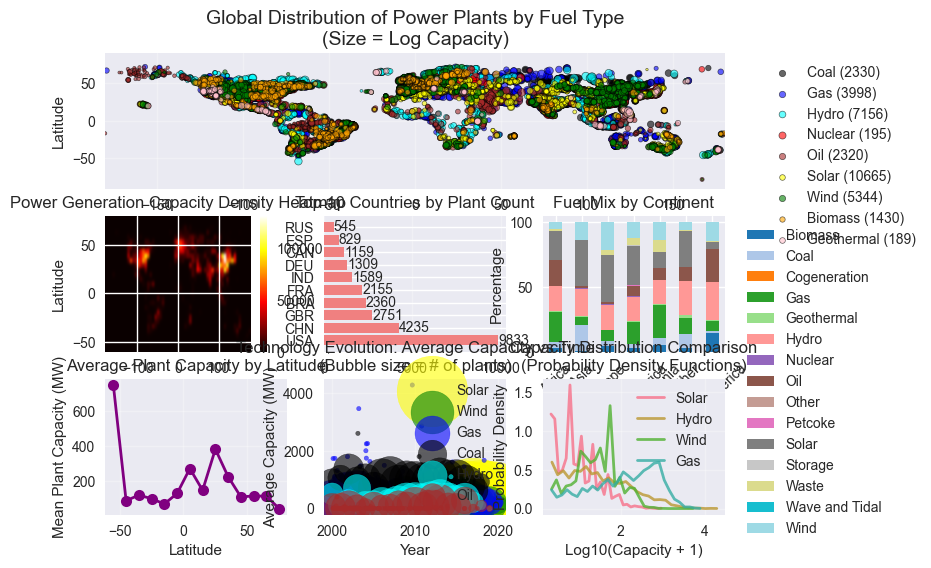


GEOGRAPHICAL ANALYSIS SUMMARY
--------------------------------------------------
Global Coverage:
  Latitude range: -77.8° to 71.3°
  Longitude range: -180.0° to 179.4°
  Countries represented: 167

Continent Distribution:
continent
North America    11314
Europe           11029
Asia              6914
South America     3280
Other             1263
Africa             593
Oceania            543
Name: count, dtype: int64

Top 5 Countries by Total Capacity:
country
CHN    1415067.4
USA    1204638.0
IND     316088.5
RUS     228220.0
JPN     215365.8
Name: capacity_mw, dtype: float64


In [13]:
print("ADVANCED VISUALIZATION AND GEOGRAPHICAL ANALYSIS")
print("="*70)

# geographical data
geo_data = df_clean.dropna(subset=['latitude', 'longitude', 'capacity_mw']).copy()
print(f"Plants with valid coordinates: {len(geo_data)}")

fig = plt.figure(figsize=(24, 20))

# 1. Global geographical distribution 
ax1 = plt.subplot(3, 3, (1, 3))

# Create scatter plot with capacity-based sizing and fuel-based coloring
fuel_colors = {
    'Coal': 'black',
    'Gas': 'blue', 
    'Hydro': 'cyan',
    'Nuclear': 'red',
    'Oil': 'brown',
    'Solar': 'yellow',
    'Wind': 'green',
    'Biomass': 'orange',
    'Geothermal': 'pink'
}

# Plot different fuel types with different colors
for fuel in fuel_colors.keys():
    fuel_data = geo_data[geo_data['primary_fuel'] == fuel]
    if len(fuel_data) > 0:
        # Size based on log capacity for better visualization
        sizes = np.log10(fuel_data['capacity_mw'] + 1) * 10
        ax1.scatter(fuel_data['longitude'], fuel_data['latitude'], 
                   c=fuel_colors[fuel], s=sizes, alpha=0.6, 
                   label=f'{fuel} ({len(fuel_data)})', edgecolors='black', linewidths=0.5)

ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
ax1.set_title('Global Distribution of Power Plants by Fuel Type\n(Size = Log Capacity)', fontsize=14)
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(-180, 180)
ax1.set_ylim(-90, 90)

# 2. Capacity density heatmap
ax2 = plt.subplot(3, 3, 4)

# Create 2D histogram of capacity density
lat_bins = np.linspace(-60, 80, 30)  
lon_bins = np.linspace(-180, 180, 60)

# Calculate total capacity in each grid cell
H, xedges, yedges = np.histogram2d(geo_data['longitude'], geo_data['latitude'], 
                                   bins=[lon_bins, lat_bins], weights=geo_data['capacity_mw'])

# Create heatmap
im = ax2.imshow(H.T, origin='lower', extent=[-180, 180, -60, 80], 
                cmap='hot', aspect='auto', interpolation='gaussian')
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')
ax2.set_title('Power Generation Capacity Density Heatmap')
plt.colorbar(im, ax=ax2, label='Total Capacity (MW)')

# 3. Regional analysis - Top countries
ax3 = plt.subplot(3, 3, 5)
top_countries = geo_data['country'].value_counts().head(10)
bars = ax3.barh(range(len(top_countries)), top_countries.values, color='lightcoral')
ax3.set_yticks(range(len(top_countries)))
ax3.set_yticklabels(top_countries.index)
ax3.set_xlabel('Number of Power Plants')
ax3.set_title('Top 10 Countries by Plant Count')
ax3.grid(True, alpha=0.3, axis='x')

# Add value labels
for i, (bar, value) in enumerate(zip(bars, top_countries.values)):
    ax3.text(value + 20, bar.get_y() + bar.get_height()/2, 
             f'{value}', va='center', ha='left')

# 4. Fuel mix by continent
ax4 = plt.subplot(3, 3, 6)

# Approximate continent mapping based on coordinates
def get_continent(lat, lon):
    if lat > 30 and -15 < lon < 60:  # Europe
        return 'Europe'
    elif lat > 15 and lon > 60:  # Asia
        return 'Asia'
    elif lat > 15 and lon < -60:  # North America
        return 'North America'
    elif lat < 15 and -90 < lon < -30:  # South America
        return 'South America'
    elif lat < 30 and 10 < lon < 60:  # Africa
        return 'Africa'
    elif lat < -10 and lon > 110:  # Oceania
        return 'Oceania'
    else:
        return 'Other'

geo_data['continent'] = geo_data.apply(lambda row: get_continent(row['latitude'], row['longitude']), axis=1)

# Create fuel mix by continent
continent_fuel = pd.crosstab(geo_data['continent'], geo_data['primary_fuel'], normalize='index') * 100

# Plot stacked bar chart
continent_fuel.plot(kind='bar', stacked=True, ax=ax4, 
                   colormap='tab20', figsize=(8, 6))
ax4.set_xlabel('Continent')
ax4.set_ylabel('Percentage')
ax4.set_title('Fuel Mix by Continent')
ax4.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax4.tick_params(axis='x', rotation=45)

# 5. Capacity vs Latitude analysis
ax5 = plt.subplot(3, 3, 7)

# Bin by latitude and calculate statistics
lat_bins_analysis = np.arange(-60, 81, 10)
lat_centers = (lat_bins_analysis[:-1] + lat_bins_analysis[1:]) / 2

lat_capacity_stats = []
for i in range(len(lat_bins_analysis)-1):
    lat_subset = geo_data[(geo_data['latitude'] >= lat_bins_analysis[i]) & 
                         (geo_data['latitude'] < lat_bins_analysis[i+1])]
    if len(lat_subset) > 0:
        lat_capacity_stats.append({
            'lat_center': lat_centers[i],
            'mean_capacity': lat_subset['capacity_mw'].mean(),
            'total_capacity': lat_subset['capacity_mw'].sum(),
            'plant_count': len(lat_subset)
        })

lat_stats_df = pd.DataFrame(lat_capacity_stats)

# Plot mean capacity by latitude
ax5.plot(lat_stats_df['lat_center'], lat_stats_df['mean_capacity'], 
         marker='o', linewidth=2, markersize=8, color='purple')
ax5.set_xlabel('Latitude')
ax5.set_ylabel('Mean Plant Capacity (MW)')
ax5.set_title('Average Plant Capacity by Latitude')
ax5.grid(True, alpha=0.3)

# 6. Technology evolution bubble chart
ax6 = plt.subplot(3, 3, 8)

# Focus on recent years and major technologies
recent_data = geo_data[geo_data['commissioning_year'] >= 2000]
major_fuels_recent = recent_data['primary_fuel'].value_counts().head(6).index

for i, fuel in enumerate(major_fuels_recent):
    fuel_subset = recent_data[recent_data['primary_fuel'] == fuel]
    
    # Calculate 5-year averages
    fuel_yearly = fuel_subset.groupby('commissioning_year').agg({
        'capacity_mw': ['mean', 'count']
    }).round(2)
    
    fuel_yearly.columns = ['mean_capacity', 'count']
    fuel_yearly = fuel_yearly.reset_index()
    
    # Create bubble plot
    if len(fuel_yearly) > 0:
        ax6.scatter(fuel_yearly['commissioning_year'], 
                   fuel_yearly['mean_capacity'],
                   s=fuel_yearly['count'] * 10,  # Size based on count
                   alpha=0.6, label=fuel,
                   color=fuel_colors.get(fuel, 'gray'))

ax6.set_xlabel('Year')
ax6.set_ylabel('Average Capacity (MW)')
ax6.set_title('Technology Evolution: Average Capacity vs Time\n(Bubble size = # of plants)')
ax6.legend()
ax6.grid(True, alpha=0.3)

# 7. Statistical distribution comparison
ax7 = plt.subplot(3, 3, 9)

# Compare capacity distributions for major fuel types
major_fuels = geo_data['primary_fuel'].value_counts().head(4).index

for fuel in major_fuels:
    fuel_capacities = geo_data[geo_data['primary_fuel'] == fuel]['capacity_mw']
    
    # Calculate probability density using numpy
    log_capacities = np.log10(fuel_capacities + 1)
    
    # Create histogram for PDF estimation
    counts, bins = np.histogram(log_capacities, bins=30, density=True)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    ax7.plot(bin_centers, counts, linewidth=2, label=fuel, alpha=0.8)

ax7.set_xlabel('Log10(Capacity + 1)')
ax7.set_ylabel('Probability Density')
ax7.set_title('Capacity Distribution Comparison\n(Probability Density Functions)')
ax7.legend()
ax7.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nGEOGRAPHICAL ANALYSIS SUMMARY")
print("-"*50)

print(f"Global Coverage:")
print(f"  Latitude range: {geo_data['latitude'].min():.1f}° to {geo_data['latitude'].max():.1f}°")
print(f"  Longitude range: {geo_data['longitude'].min():.1f}° to {geo_data['longitude'].max():.1f}°")
print(f"  Countries represented: {geo_data['country'].nunique()}")

print(f"\nContinent Distribution:")
continent_summary = geo_data['continent'].value_counts()
print(continent_summary)

print(f"\nTop 5 Countries by Total Capacity:")
country_capacity_geo = geo_data.groupby('country')['capacity_mw'].sum().sort_values(ascending=False).head(5)
print(country_capacity_geo.round(1))

## Task 6: Matrix Operations in Real-World Context



MATRIX OPERATIONS IN REAL-WORLD CONTEXT
Feature matrix shape: (17447, 5)
Features: ['capacity_mw', 'latitude', 'longitude', 'age', 'capacity_log']

1. COVARIANCE MATRIX ANALYSIS
--------------------------------------------------
Covariance matrix shape: (5, 5)

Covariance Matrix:
              capacity_mw  latitude  longitude     age  capacity_log
capacity_mw        1.0000    0.0091     0.3398  0.0139        0.6539
latitude           0.0091    1.0000    -0.1031  0.1522        0.0137
longitude          0.3398   -0.1031     1.0000  0.0237        0.4621
age                0.0139    0.1522     0.0237  1.0000        0.1099
capacity_log       0.6539    0.0137     0.4621  0.1099        1.0000

2. EIGENVALUE AND EIGENVECTOR ANALYSIS
--------------------------------------------------
Eigenvalues (sorted):
  λ1: 1.9913
  λ2: 1.1673
  λ3: 0.8616
  λ4: 0.6584
  λ5: 0.3215

Eigenvalue properties:
  Sum of eigenvalues: 5.0000
  Trace of covariance matrix: 5.0000
  Determinant: 0.4239
  Condition num

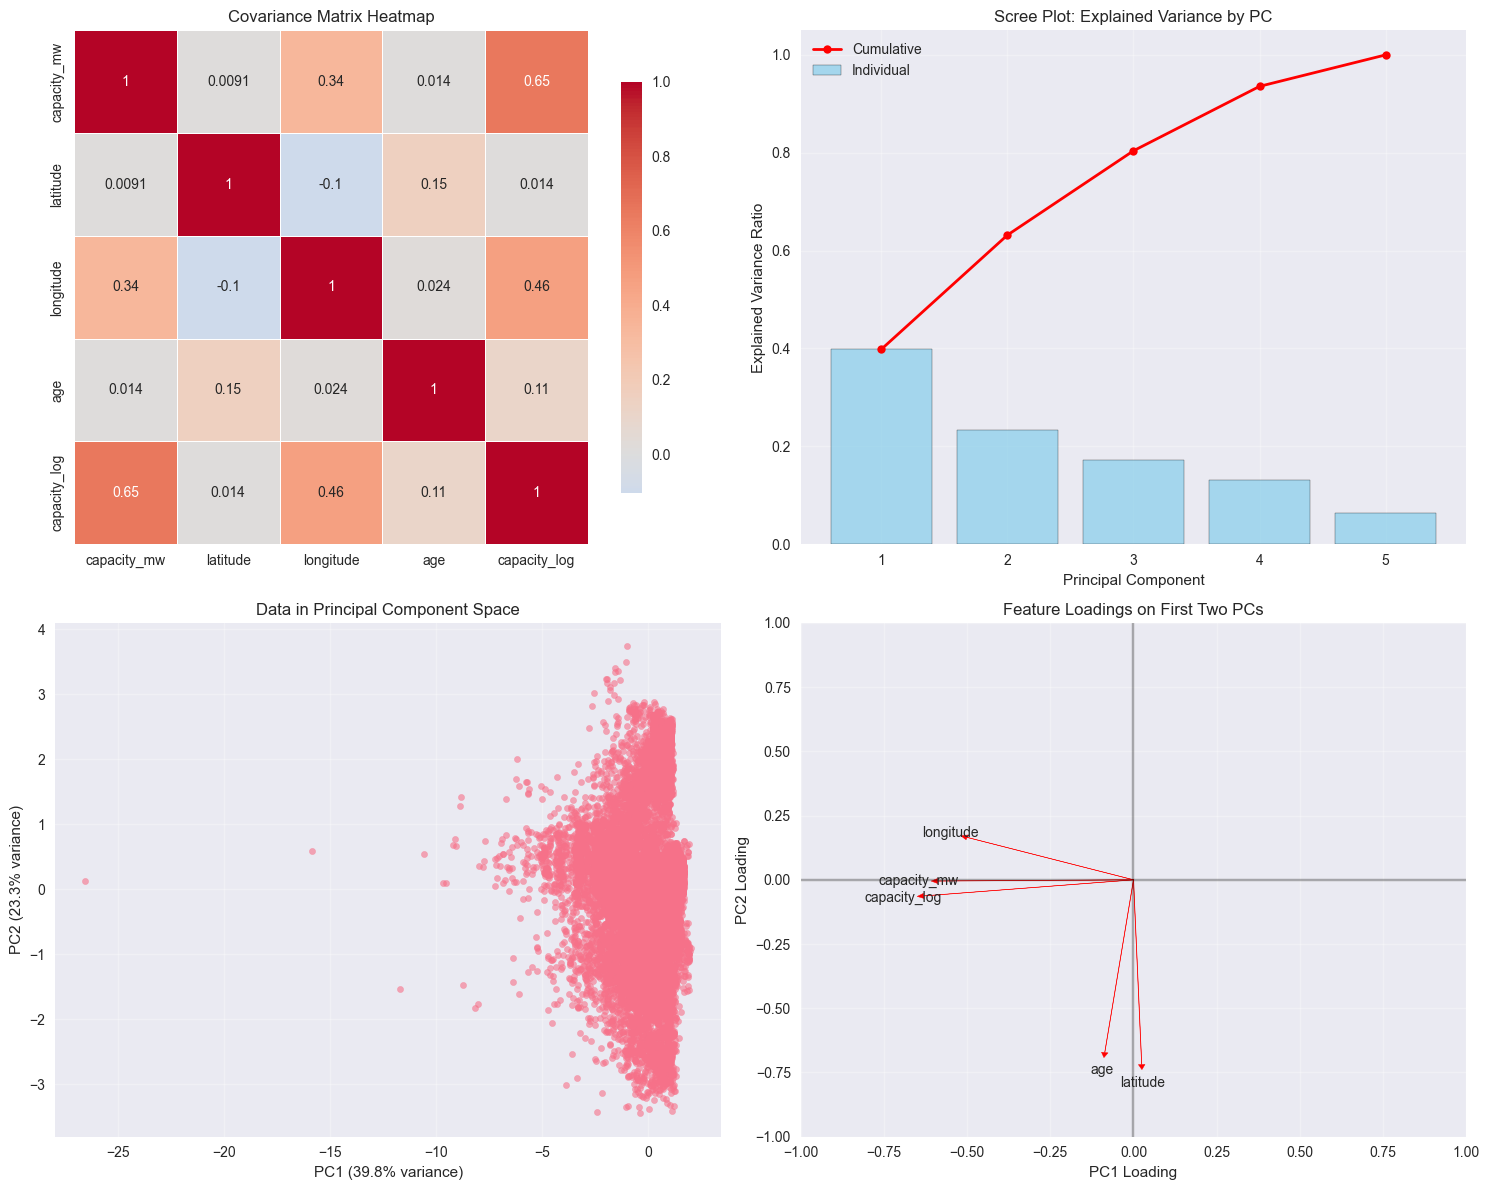


4. MATRIX DECOMPOSITION ANALYSIS
--------------------------------------------------
SVD Decomposition:
  U matrix shape: (17447, 5)
  Singular values shape: (5,)
  V^T matrix shape: (5, 5)

Singular values:
  σ1: 186.3850
  σ2: 142.7039
  σ3: 122.6036
  σ4: 107.1723
  σ5: 74.8913

Relationship between SVD and Eigendecomposition:
  Singular values squared / (n-1): [1.9913 1.1673 0.8616 0.6584 0.3215]
  Eigenvalues: [1.9913 1.1673 0.8616 0.6584 0.3215]

5. DIMENSIONALITY REDUCTION ANALYSIS
--------------------------------------------------
  1 components: Reconstruction error = 0.601715
  2 components: Reconstruction error = 0.368272
  3 components: Reconstruction error = 0.195960
  4 components: Reconstruction error = 0.064294
  5 components: Reconstruction error = 0.000000


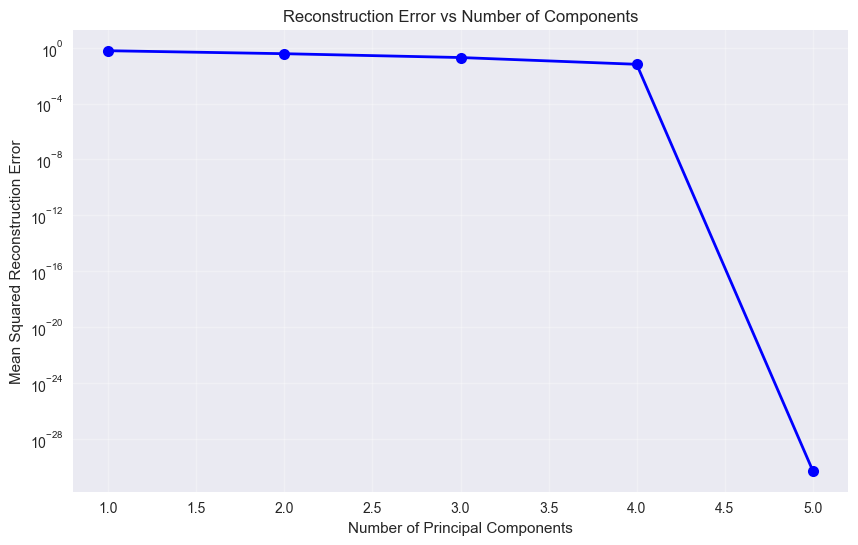


6. REAL-WORLD INTERPRETATION
--------------------------------------------------
Principal Component Interpretation:
  PC1 (39.8% variance):
    capacity_mw: -0.588
    latitude: 0.025
    longitude: -0.500
    age: -0.086
    capacity_log: -0.630

  PC2 (23.3% variance):
    capacity_mw: -0.005
    latitude: -0.719
    longitude: 0.165
    age: -0.672
    capacity_log: -0.063

Dominant Features:
  PC1 most influenced by: capacity_log
  PC2 most influenced by: latitude

Matrix Stability Analysis:
  Condition number: 6.19
  Matrix rank: 5
  Is positive definite: True
  Matrix is well-conditioned for numerical operations


In [14]:
print("MATRIX OPERATIONS IN REAL-WORLD CONTEXT")
print("="*70)

# Prepare data for matrix operations
matrix_data = df_clean[['capacity_mw', 'latitude', 'longitude', 'commissioning_year']].dropna()

# Add derived features
matrix_data = matrix_data.copy()
matrix_data['age'] = 2024 - matrix_data['commissioning_year']
matrix_data['capacity_log'] = np.log10(matrix_data['capacity_mw'] + 1)

# Create feature matrix
feature_cols = ['capacity_mw', 'latitude', 'longitude', 'age', 'capacity_log']
X = matrix_data[feature_cols].values

print(f"Feature matrix shape: {X.shape}")
print(f"Features: {feature_cols}")

# 1. Covariance Matrix Analysis
print(f"\n1. COVARIANCE MATRIX ANALYSIS")
print("-"*50)

# Standardize the data
X_standardized = (X - np.mean(X, axis=0)) / np.std(X, axis=0, ddof=1)

# Calculate covariance matrix
cov_matrix = np.cov(X_standardized.T)
print(f"Covariance matrix shape: {cov_matrix.shape}")

# Create covariance DataFrame for better visualization
cov_df = pd.DataFrame(cov_matrix, index=feature_cols, columns=feature_cols)
print("\nCovariance Matrix:")
print(cov_df.round(4))

plt.figure(figsize=(15, 12))

plt.subplot(2, 2, 1)
sns.heatmap(cov_df, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": .8})
plt.title('Covariance Matrix Heatmap')

# 2. Eigenvalue and Eigenvector Analysis
print(f"\n2. EIGENVALUE AND EIGENVECTOR ANALYSIS")
print("-"*50)

# Calculate eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Sort eigenvalues and eigenvectors in descending order
sort_indices = np.argsort(eigenvalues)[::-1]
eigenvalues_sorted = eigenvalues[sort_indices]
eigenvectors_sorted = eigenvectors[:, sort_indices]

print("Eigenvalues (sorted):")
for i, eigenval in enumerate(eigenvalues_sorted):
    print(f"  λ{i+1}: {eigenval:.4f}")

print(f"\nEigenvalue properties:")
print(f"  Sum of eigenvalues: {np.sum(eigenvalues_sorted):.4f}")
print(f"  Trace of covariance matrix: {np.trace(cov_matrix):.4f}")
print(f"  Determinant: {np.linalg.det(cov_matrix):.4f}")
print(f"  Condition number: {np.linalg.cond(cov_matrix):.4f}")

# Explained variance ratio
explained_variance_ratio = eigenvalues_sorted / np.sum(eigenvalues_sorted)
cumulative_variance = np.cumsum(explained_variance_ratio)

print(f"\nExplained Variance Ratio:")
for i, (ratio, cumulative) in enumerate(zip(explained_variance_ratio, cumulative_variance)):
    print(f"  PC{i+1}: {ratio:.4f} ({ratio*100:.1f}%) - Cumulative: {cumulative:.4f} ({cumulative*100:.1f}%)")

# Eigenvector analysis
print(f"\nEigenvectors (Principal Components):")
eigenvector_df = pd.DataFrame(eigenvectors_sorted, 
                             index=feature_cols, 
                             columns=[f'PC{i+1}' for i in range(len(feature_cols))])
print(eigenvector_df.round(4))

# 3. Principal Component Analysis (PCA)
print(f"\n3. PRINCIPAL COMPONENT ANALYSIS")
print("-"*50)

# Transform data to principal component space
X_pca = X_standardized @ eigenvectors_sorted

print(f"PCA-transformed data shape: {X_pca.shape}")

# Calculate principal component scores
pc_scores = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])

print(f"\nPrincipal Component Statistics:")
print(pc_scores.describe().round(4))

# Visualizations
plt.subplot(2, 2, 2)
plt.bar(range(1, len(eigenvalues_sorted)+1), explained_variance_ratio, 
        alpha=0.7, color='skyblue', edgecolor='black')
plt.plot(range(1, len(eigenvalues_sorted)+1), cumulative_variance, 
         'ro-', color='red', linewidth=2, markersize=6)
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot: Explained Variance by PC')
plt.grid(True, alpha=0.3)
plt.legend(['Cumulative', 'Individual'])

# PC1 vs PC2 scatter plot
plt.subplot(2, 2, 3)
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6, s=20)
plt.xlabel(f'PC1 ({explained_variance_ratio[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({explained_variance_ratio[1]*100:.1f}% variance)')
plt.title('Data in Principal Component Space')
plt.grid(True, alpha=0.3)

# Eigenvector visualization (loadings plot)
plt.subplot(2, 2, 4)
for i, feature in enumerate(feature_cols):
    plt.arrow(0, 0, eigenvectors_sorted[i, 0], eigenvectors_sorted[i, 1], 
              head_width=0.02, head_length=0.02, fc='red', ec='red')
    plt.text(eigenvectors_sorted[i, 0]*1.1, eigenvectors_sorted[i, 1]*1.1, 
             feature, fontsize=10, ha='center', va='center')

plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.xlabel('PC1 Loading')
plt.ylabel('PC2 Loading')
plt.title('Feature Loadings on First Two PCs')
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='k', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='k', linestyle='-', alpha=0.3)

plt.tight_layout()
plt.show()

# 4. Matrix Decomposition Analysis
print(f"\n4. MATRIX DECOMPOSITION ANALYSIS")
print("-"*50)

# Singular Value Decomposition (SVD)
U, s, Vt = np.linalg.svd(X_standardized, full_matrices=False)

print(f"SVD Decomposition:")
print(f"  U matrix shape: {U.shape}")
print(f"  Singular values shape: {s.shape}")
print(f"  V^T matrix shape: {Vt.shape}")

print(f"\nSingular values:")
for i, sv in enumerate(s):
    print(f"  σ{i+1}: {sv:.4f}")

# Relationship between SVD and eigendecomposition
print(f"\nRelationship between SVD and Eigendecomposition:")
print(f"  Singular values squared / (n-1): {(s**2 / (X_standardized.shape[0]-1)).round(4)}")
print(f"  Eigenvalues: {eigenvalues_sorted.round(4)}")

# Reconstruction using different numbers of components
print(f"\n5. DIMENSIONALITY REDUCTION ANALYSIS")
print("-"*50)

reconstruction_errors = []
components_range = range(1, len(feature_cols)+1)

for n_components in components_range:
    # Reconstruct using first n principal components
    X_reconstructed = X_pca[:, :n_components] @ eigenvectors_sorted[:, :n_components].T
    
    # Calculate reconstruction error
    reconstruction_error = np.mean((X_standardized - X_reconstructed)**2)
    reconstruction_errors.append(reconstruction_error)
    
    print(f"  {n_components} components: Reconstruction error = {reconstruction_error:.6f}")

# Visualize reconstruction error
plt.figure(figsize=(10, 6))
plt.plot(components_range, reconstruction_errors, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Principal Components')
plt.ylabel('Mean Squared Reconstruction Error')
plt.title('Reconstruction Error vs Number of Components')
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.show()

# 6. Real-world interpretation
print(f"\n6. REAL-WORLD INTERPRETATION")
print("-"*50)

print(f"Principal Component Interpretation:")
print(f"  PC1 ({explained_variance_ratio[0]*100:.1f}% variance):")
pc1_loadings = eigenvectors_sorted[:, 0]
for i, (feature, loading) in enumerate(zip(feature_cols, pc1_loadings)):
    print(f"    {feature}: {loading:.3f}")

print(f"\n  PC2 ({explained_variance_ratio[1]*100:.1f}% variance):")
pc2_loadings = eigenvectors_sorted[:, 1]
for i, (feature, loading) in enumerate(zip(feature_cols, pc2_loadings)):
    print(f"    {feature}: {loading:.3f}")

# Dominant features in each PC
print(f"\nDominant Features:")
pc1_dominant = feature_cols[np.argmax(np.abs(pc1_loadings))]
pc2_dominant = feature_cols[np.argmax(np.abs(pc2_loadings))]
print(f"  PC1 most influenced by: {pc1_dominant}")
print(f"  PC2 most influenced by: {pc2_dominant}")

# Matrix condition and stability analysis
print(f"\nMatrix Stability Analysis:")
print(f"  Condition number: {np.linalg.cond(cov_matrix):.2f}")
print(f"  Matrix rank: {np.linalg.matrix_rank(cov_matrix)}")
print(f"  Is positive definite: {np.all(eigenvalues_sorted > 0)}")

if np.linalg.cond(cov_matrix) > 1000:
    print("  Warning: High condition number indicates potential numerical instability")
else:
    print("  Matrix is well-conditioned for numerical operations")

## Task 7: Integrating NumPy with Pandas and Matplotlib

Demonstrate advanced integration techniques showing how NumPy enhances Pandas operations and Matplotlib visualizations.

ADVANCED INTEGRATION TECHNIQUES
1. NUMPY-ENHANCED PANDAS OPERATIONS
--------------------------------------------------
75th percentile capacity: 75.3 MW
Large plants (>75th percentile, post-2000): 3236

Feature Engineering with NumPy:
Distance to major cities calculated for 34936 plants
Average distance to nearest major city: 2130.5 km

2. NUMPY-POWERED STATISTICAL ANALYSIS
--------------------------------------------------
Distance to major cities calculated for 34936 plants
Average distance to nearest major city: 2130.5 km

2. NUMPY-POWERED STATISTICAL ANALYSIS
--------------------------------------------------
Top 10 countries by total capacity (with advanced statistics):
         count        total     mean  median       std          var     cv  \
country                                                                      
CHN       4235  1415067.380  334.136    49.0   810.241   656490.466  2.425   
USA       9833  1204638.050  122.510     8.2   345.781   119564.741  2.822   
IND 

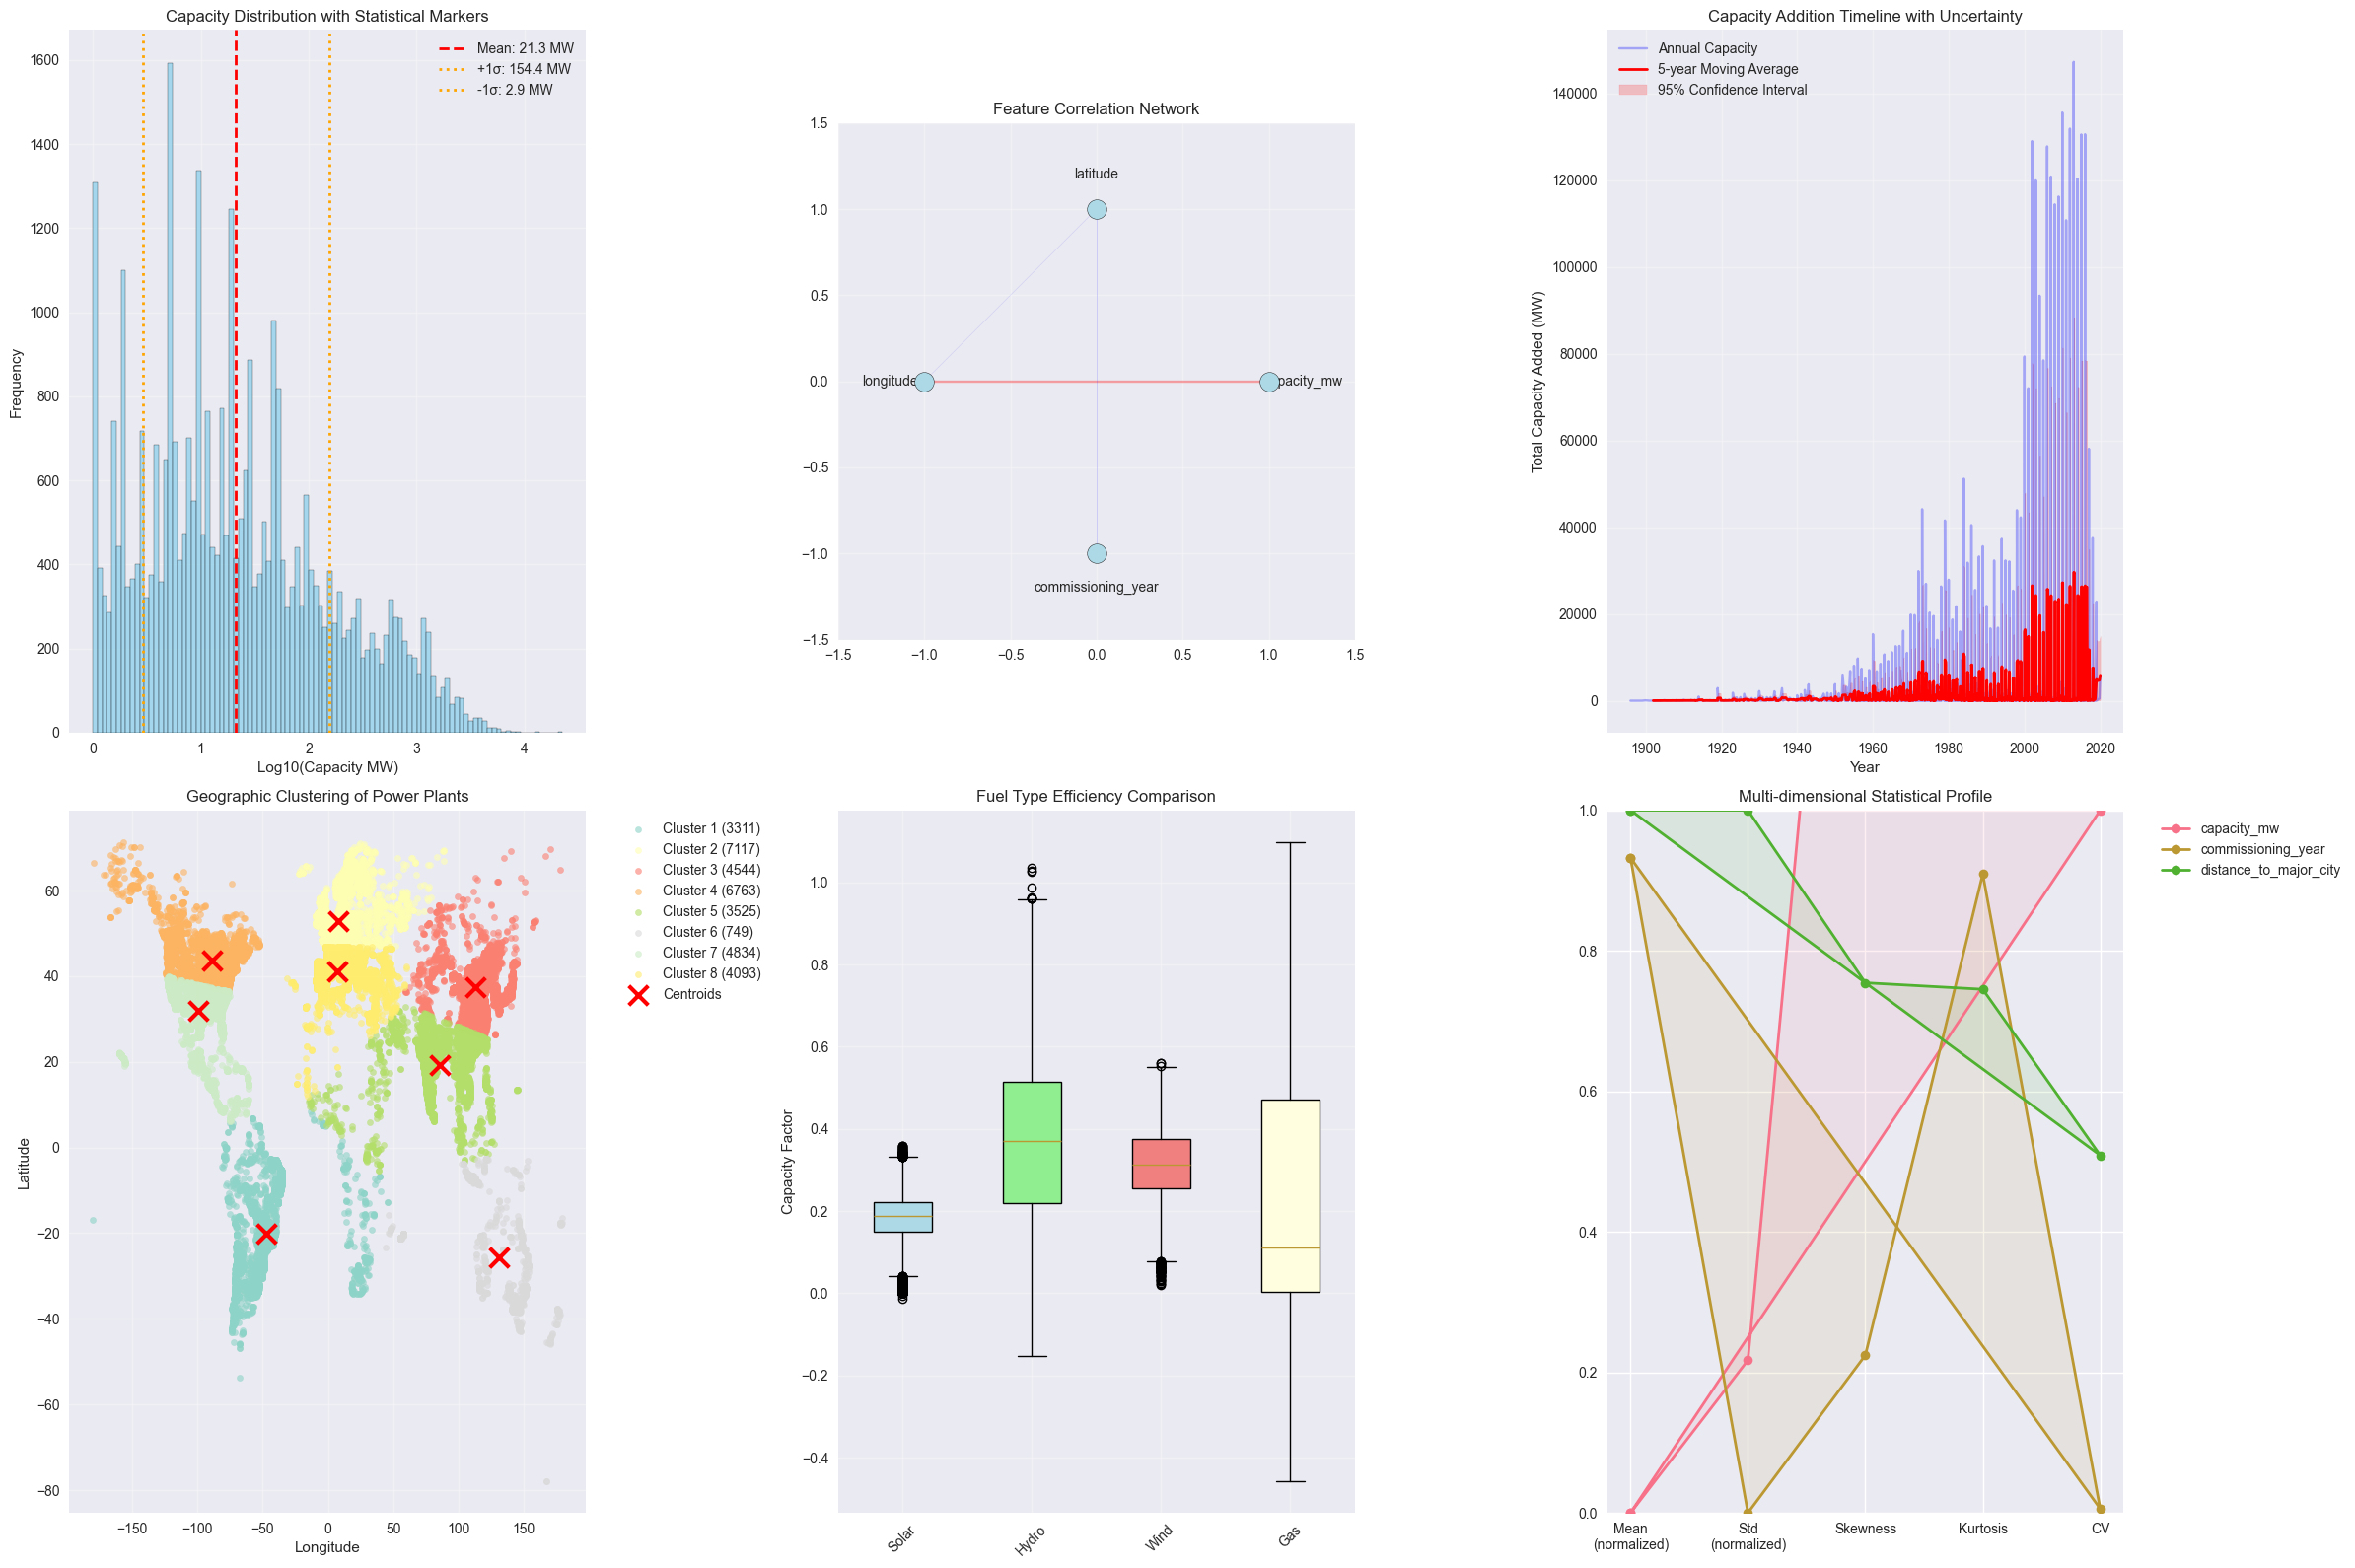


Integration Summary:
  Total plants analyzed: 34936
  Geographic clusters identified: 8
  Features with statistical profiles: 3
  Advanced visualizations created: 6


In [15]:
print("ADVANCED INTEGRATION TECHNIQUES")
print("="*70)

print("1. NUMPY-ENHANCED PANDAS OPERATIONS")
print("-"*50)

# Advanced filtering using NumPy boolean operations
capacity_threshold = np.percentile(df_clean['capacity_mw'].dropna(), 75)
print(f"75th percentile capacity: {capacity_threshold:.1f} MW")

# Complex filtering using NumPy
large_plants = df_clean[
    (df_clean['capacity_mw'] > capacity_threshold) & 
    (df_clean['commissioning_year'] >= 2000)
].copy()

print(f"Large plants (>75th percentile, post-2000): {len(large_plants)}")

# NumPy-based feature engineering
print(f"\nFeature Engineering with NumPy:")

# Capacity categories using NumPy
capacity_values = df_clean['capacity_mw'].dropna().values
capacity_percentiles = np.percentile(capacity_values, [25, 50, 75, 90])

def categorize_capacity(capacity):
    if pd.isna(capacity):
        return 'Unknown'
    elif capacity <= capacity_percentiles[0]:
        return 'Small'
    elif capacity <= capacity_percentiles[1]:
        return 'Medium'
    elif capacity <= capacity_percentiles[2]:
        return 'Large'
    elif capacity <= capacity_percentiles[3]:
        return 'Very Large'
    else:
        return 'Massive'

df_clean['capacity_category'] = df_clean['capacity_mw'].apply(categorize_capacity)

# Distance from major cities using NumPy vectorized operations
major_cities = {
    'New York': (40.7128, -74.0060),
    'London': (51.5074, -0.1278),
    'Tokyo': (35.6762, 139.6503),
    'Beijing': (39.9042, 116.4074),
    'Mumbai': (19.0760, 72.8777)
}

def calculate_distance_vectorized(lat1, lon1, lat2, lon2):
    """Calculate great circle distance using NumPy vectorized operations"""
    # Convert to radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    # Haversine formula
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    # Earth's radius in kilometers
    r = 6371
    return r * c

# Calculate distances to nearest major city
geo_plants = df_clean.dropna(subset=['latitude', 'longitude']).copy()

distances_to_cities = []
for city, (city_lat, city_lon) in major_cities.items():
    distances = calculate_distance_vectorized(
        geo_plants['latitude'].values,
        geo_plants['longitude'].values,
        city_lat, city_lon
    )
    distances_to_cities.append(distances)

# Find minimum distance to any major city
distances_array = np.array(distances_to_cities)
min_distances = np.min(distances_array, axis=0)
nearest_city_indices = np.argmin(distances_array, axis=0)
nearest_cities = [list(major_cities.keys())[i] for i in nearest_city_indices]

geo_plants['distance_to_major_city'] = min_distances
geo_plants['nearest_major_city'] = nearest_cities

print(f"Distance to major cities calculated for {len(geo_plants)} plants")
print(f"Average distance to nearest major city: {min_distances.mean():.1f} km")

# 2. NumPy-Powered Statistical Analysis with Pandas
print(f"\n2. NUMPY-POWERED STATISTICAL ANALYSIS")
print("-"*50)

# Advanced aggregations using NumPy functions
country_stats = df_clean.groupby('country')['capacity_mw'].agg([
    ('count', 'count'),
    ('total', np.sum),
    ('mean', np.mean),
    ('median', np.median),
    ('std', np.std),
    ('var', np.var),
    ('cv', lambda x: np.std(x) / np.mean(x)),  # Coefficient of variation
    ('iqr', lambda x: np.percentile(x, 75) - np.percentile(x, 25)),
    ('skewness', lambda x: stats.skew(x.dropna())),
    ('kurtosis', lambda x: stats.kurtosis(x.dropna()))
]).round(3)

# Filter countries with sufficient data
significant_countries = country_stats[country_stats['count'] >= 10].sort_values('total', ascending=False)
print(f"Top 10 countries by total capacity (with advanced statistics):")
print(significant_countries.head(10))

# Rolling statistics using NumPy
yearly_capacity = df_clean.groupby('commissioning_year')['capacity_mw'].sum().sort_index()

# Calculate rolling statistics with NumPy
window_size = 5
rolling_mean = np.convolve(yearly_capacity.values, np.ones(window_size)/window_size, mode='valid')
rolling_std = pd.Series(yearly_capacity.values).rolling(window=window_size).std().dropna().values

# Growth rate calculation
growth_rates = np.diff(yearly_capacity.values) / yearly_capacity.values[:-1] * 100

print(f"\nTemporal Analysis:")
print(f"  Average annual growth rate: {np.mean(growth_rates):.2f}%")
print(f"  Growth rate volatility (std): {np.std(growth_rates):.2f}%")
print(f"  Maximum growth year: {yearly_capacity.index[np.argmax(np.diff(yearly_capacity.values)) + 1]}")

# 3. Enhanced Matplotlib Visualizations with NumPy
print(f"\n3. ENHANCED MATPLOTLIB VISUALIZATIONS")
print("-"*50)

fig, axes = plt.subplots(2, 3, figsize=(24, 16))

# 1. Advanced capacity distribution with NumPy-calculated statistics
ax1 = axes[0, 0]
capacity_data = df_clean['capacity_mw'].dropna()

# Calculate optimal bins using NumPy
q25, q75 = np.percentile(capacity_data, [25, 75])
iqr = q75 - q25
bin_width = 2 * iqr / (len(capacity_data) ** (1/3))  # Freedman-Diaconis rule
n_bins = int((capacity_data.max() - capacity_data.min()) / bin_width)
n_bins = min(n_bins, 100)  # Cap at 100 bins

# Create histogram with custom bins
counts, bins, patches = ax1.hist(np.log10(capacity_data), bins=n_bins, 
                                alpha=0.7, color='skyblue', edgecolor='black')

# Add statistical annotations using NumPy
mean_log = np.mean(np.log10(capacity_data))
std_log = np.std(np.log10(capacity_data))

ax1.axvline(mean_log, color='red', linestyle='--', linewidth=2, label=f'Mean: {10**mean_log:.1f} MW')
ax1.axvline(mean_log + std_log, color='orange', linestyle=':', linewidth=2, label=f'+1σ: {10**(mean_log + std_log):.1f} MW')
ax1.axvline(mean_log - std_log, color='orange', linestyle=':', linewidth=2, label=f'-1σ: {10**(mean_log - std_log):.1f} MW')

ax1.set_xlabel('Log10(Capacity MW)')
ax1.set_ylabel('Frequency')
ax1.set_title('Capacity Distribution with Statistical Markers')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Correlation network visualization using NumPy
ax2 = axes[0, 1]

# Calculate correlation matrix for numerical features
numerical_features = ['capacity_mw', 'latitude', 'longitude', 'commissioning_year']
corr_subset = df_clean[numerical_features].dropna()

corr_matrix = np.corrcoef(corr_subset.T)

# Create correlation network plot
n_features = len(numerical_features)
angles = np.linspace(0, 2*np.pi, n_features, endpoint=False)

# Position features on a circle
positions = [(np.cos(angle), np.sin(angle)) for angle in angles]

# Draw correlation connections
for i in range(n_features):
    for j in range(i+1, n_features):
        corr_strength = abs(corr_matrix[i, j])
        if corr_strength > 0.1:  # Only show significant correlations
            x_coords = [positions[i][0], positions[j][0]]
            y_coords = [positions[i][1], positions[j][1]]
            
            # Line thickness based on correlation strength
            linewidth = corr_strength * 5
            alpha = corr_strength
            color = 'red' if corr_matrix[i, j] > 0 else 'blue'
            
            ax2.plot(x_coords, y_coords, color=color, linewidth=linewidth, alpha=alpha)

# Plot feature points
for i, (pos, feature) in enumerate(zip(positions, numerical_features)):
    ax2.scatter(pos[0], pos[1], s=200, c='lightblue', edgecolor='black', zorder=5)
    ax2.text(pos[0]*1.2, pos[1]*1.2, feature, fontsize=10, ha='center', va='center')

ax2.set_xlim(-1.5, 1.5)
ax2.set_ylim(-1.5, 1.5)
ax2.set_aspect('equal')
ax2.set_title('Feature Correlation Network')
ax2.grid(True, alpha=0.3)

# 3. Advanced time series with confidence intervals
ax3 = axes[0, 2]

# Calculate moving averages and confidence intervals
years = yearly_capacity.index.values
capacities = yearly_capacity.values

# Bootstrap confidence intervals
n_bootstrap = 1000
window = 5

bootstrap_means = []
for i in range(len(capacities) - window + 1):
    window_data = capacities[i:i+window]
    bootstrap_samples = []
    
    for _ in range(n_bootstrap):
        bootstrap_sample = np.random.choice(window_data, size=len(window_data), replace=True)
        bootstrap_samples.append(np.mean(bootstrap_sample))
    
    bootstrap_means.append(bootstrap_samples)

# Calculate confidence intervals
confidence_intervals = []
for bootstrap_samples in bootstrap_means:
    ci_lower = np.percentile(bootstrap_samples, 2.5)
    ci_upper = np.percentile(bootstrap_samples, 97.5)
    confidence_intervals.append((ci_lower, ci_upper))

# Plot with confidence intervals
years_windowed = years[window-1:]
means_windowed = [np.mean(capacities[i:i+window]) for i in range(len(capacities) - window + 1)]
ci_lower = [ci[0] for ci in confidence_intervals]
ci_upper = [ci[1] for ci in confidence_intervals]

ax3.plot(years, capacities, 'b-', alpha=0.3, label='Annual Capacity')
ax3.plot(years_windowed, means_windowed, 'r-', linewidth=2, label='5-year Moving Average')
ax3.fill_between(years_windowed, ci_lower, ci_upper, alpha=0.2, color='red', label='95% Confidence Interval')

ax3.set_xlabel('Year')
ax3.set_ylabel('Total Capacity Added (MW)')
ax3.set_title('Capacity Addition Timeline with Uncertainty')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Geographic clustering visualization
ax4 = axes[1, 0]

# K-means clustering on geographic coordinates
from sklearn.cluster import KMeans

geo_coords = geo_plants[['latitude', 'longitude']].values
n_clusters = 8

# Standardize coordinates
coords_standardized = (geo_coords - np.mean(geo_coords, axis=0)) / np.std(geo_coords, axis=0)

# Perform clustering
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
clusters = kmeans.fit_predict(coords_standardized)

# Create colormap for clusters
colors = plt.cm.Set3(np.linspace(0, 1, n_clusters))

for cluster_id in range(n_clusters):
    cluster_mask = clusters == cluster_id
    cluster_data = geo_coords[cluster_mask]
    
    if len(cluster_data) > 0:
        ax4.scatter(cluster_data[:, 1], cluster_data[:, 0], 
                   c=[colors[cluster_id]], s=20, alpha=0.6, 
                   label=f'Cluster {cluster_id+1} ({np.sum(cluster_mask)})')

# Plot cluster centers
centers_original = kmeans.cluster_centers_ * np.std(geo_coords, axis=0) + np.mean(geo_coords, axis=0)
ax4.scatter(centers_original[:, 1], centers_original[:, 0], 
           c='red', s=200, marker='x', linewidths=3, label='Centroids')

ax4.set_xlabel('Longitude')
ax4.set_ylabel('Latitude')
ax4.set_title('Geographic Clustering of Power Plants')
ax4.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax4.grid(True, alpha=0.3)

# 5. Fuel efficiency analysis using NumPy
ax5 = axes[1, 1]

# Calculate fuel efficiency metrics
fuel_efficiency = {}
generation_cols = [col for col in df_clean.columns if 'generation_gwh' in col and 'estimated' not in col]

for fuel in major_fuels[:6]:  # Top 6 fuels
    fuel_data = df_clean[df_clean['primary_fuel'] == fuel]
    
    # Calculate average capacity factor (generation / (capacity * 8760))
    efficiency_metrics = []
    
    for gen_col in generation_cols:
        valid_data = fuel_data.dropna(subset=['capacity_mw', gen_col])
        if len(valid_data) > 0:
            # Capacity factor calculation
            theoretical_max = valid_data['capacity_mw'] * 8760 / 1000  # Convert to GWh
            capacity_factors = valid_data[gen_col] / theoretical_max
            
            # Remove outliers using NumPy
            q1, q3 = np.percentile(capacity_factors, [25, 75])
            iqr = q3 - q1
            lower_bound = q1 - 1.5 * iqr
            upper_bound = q3 + 1.5 * iqr
            
            clean_factors = capacity_factors[(capacity_factors >= lower_bound) & 
                                           (capacity_factors <= upper_bound)]
            
            if len(clean_factors) > 0:
                efficiency_metrics.extend(clean_factors)
    
    if efficiency_metrics:
        fuel_efficiency[fuel] = np.array(efficiency_metrics)

# Create box plot
fuel_names = list(fuel_efficiency.keys())
efficiency_data = [fuel_efficiency[fuel] for fuel in fuel_names]

bp = ax5.boxplot(efficiency_data, labels=fuel_names, patch_artist=True)

# Color boxes
colors_fuel = ['lightblue', 'lightgreen', 'lightcoral', 'lightyellow', 'lightpink', 'lightgray']
for patch, color in zip(bp['boxes'], colors_fuel[:len(bp['boxes'])]):
    patch.set_facecolor(color)

ax5.set_ylabel('Capacity Factor')
ax5.set_title('Fuel Type Efficiency Comparison')
ax5.tick_params(axis='x', rotation=45)
ax5.grid(True, alpha=0.3)

# 6. Advanced statistical summary using NumPy
ax6 = axes[1, 2]

# Multi-dimensional statistical analysis
feature_stats = {}
analysis_features = ['capacity_mw', 'commissioning_year', 'distance_to_major_city']

for feature in analysis_features:
    if feature in geo_plants.columns:
        data = geo_plants[feature].dropna()
        
        feature_stats[feature] = {
            'mean': np.mean(data),
            'std': np.std(data),
            'skewness': stats.skew(data),
            'kurtosis': stats.kurtosis(data),
            'cv': np.std(data) / np.mean(data)
        }

# Create radar chart
categories = ['Mean\n(normalized)', 'Std\n(normalized)', 'Skewness', 'Kurtosis', 'CV']
angles = np.linspace(0, 2*np.pi, len(categories), endpoint=False)

# Normalize means and stds for comparison
means_norm = [feature_stats[feat]['mean'] for feat in analysis_features if feat in feature_stats]
stds_norm = [feature_stats[feat]['std'] for feat in analysis_features if feat in feature_stats]

# Normalize to 0-1 scale
means_norm = (np.array(means_norm) - np.min(means_norm)) / (np.max(means_norm) - np.min(means_norm))
stds_norm = (np.array(stds_norm) - np.min(stds_norm)) / (np.max(stds_norm) - np.min(stds_norm))

# Plot each feature as separate line
for i, feature in enumerate([feat for feat in analysis_features if feat in feature_stats]):
    values = [
        means_norm[i],
        stds_norm[i],
        (feature_stats[feature]['skewness'] + 3) / 6,  # Normalize skewness
        (feature_stats[feature]['kurtosis'] + 3) / 6,  # Normalize kurtosis
        min(feature_stats[feature]['cv'], 2) / 2       # Cap and normalize CV
    ]
    
    # Close the plot
    values_plot = values + [values[0]]
    angles_plot = np.concatenate([angles, [angles[0]]])
    
    ax6.plot(angles_plot, values_plot, 'o-', linewidth=2, label=feature)
    ax6.fill(angles_plot, values_plot, alpha=0.1)

ax6.set_xticks(angles)
ax6.set_xticklabels(categories)
ax6.set_ylim(0, 1)
ax6.set_title('Multi-dimensional Statistical Profile')
ax6.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax6.grid(True)

plt.tight_layout()
plt.show()

print(f"\nIntegration Summary:")
print(f"  Total plants analyzed: {len(df_clean)}")
print(f"  Geographic clusters identified: {n_clusters}")
print(f"  Features with statistical profiles: {len(feature_stats)}")
print(f"  Advanced visualizations created: 6")

## Summary and Conclusions

This comprehensive analysis demonstrates the power of integrating NumPy, Pandas, and Matplotlib for real-world data analysis. Key insights and methodologies applied:

COMPREHENSIVE ANALYSIS SUMMARY
✅ Dataset loaded successfully for summary
Original records: 34,936
Clean records: 34,936

DATA QUALITY:
------------------------------
  Total Records: 34,936
  Clean Records: 34,936
  Data Completeness: 100.0%
  Countries Represented: 167
  Fuel Types: 15

STATISTICAL INSIGHTS:
------------------------------
  Total Global Capacity: 5,706,975 MW
  Average Plant Size: 163.4 MW
  Largest Plant: 22,500 MW
  Smallest Plant: 1.0 MW
  Capacity Std Dev: 489.6 MW

TEMPORAL TRENDS:
------------------------------
  Analysis Period: 1900 - 2020
  Plants with Dates: 17,445
  Most Recent Plants: 150 since 2020
  Historical Plants: 3205 before 1980

GEOGRAPHIC DISTRIBUTION:
------------------------------
  Global Coverage: Lat: -77.8° to 71.3°
  Longitude Range: Lon: -180.0° to 179.4°
  Plants with Coordinates: 34,936
  Countries with Data: 167
  Coordinate Completeness: 100.0%

FUEL TYPE ANALYSIS:
------------------------------
  Most Common Fuel: Solar
  Coal Plants

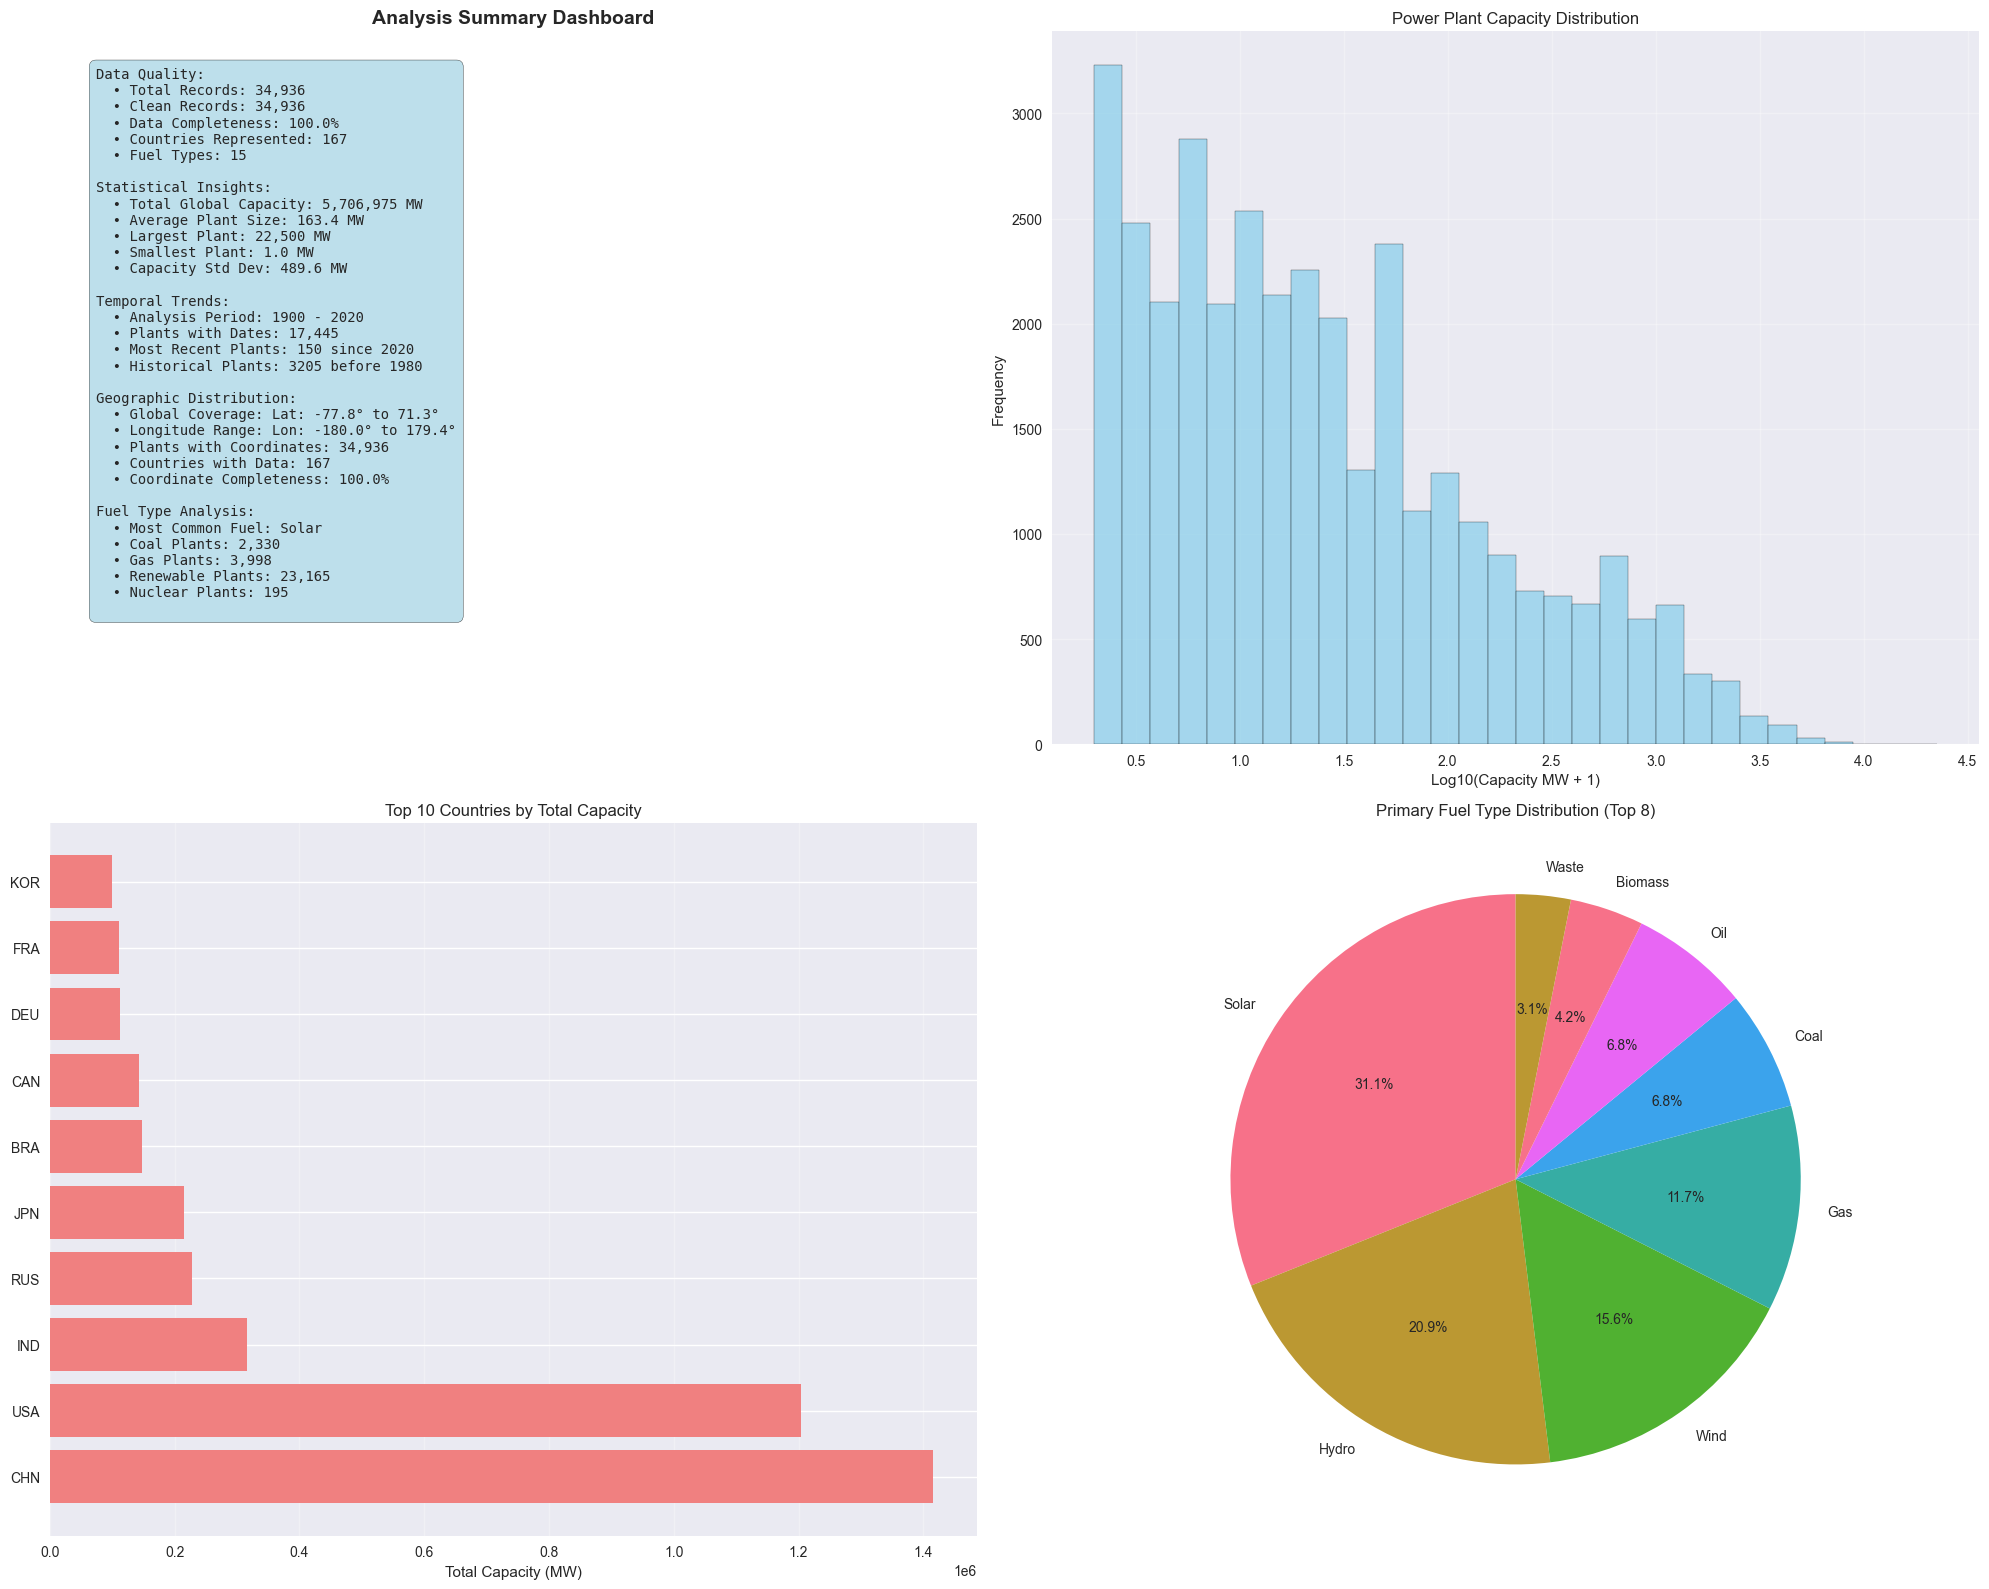


METHODOLOGY SUMMARY

NumPy Techniques:
  • Advanced array operations for statistical analysis
  • Vectorized distance calculations
  • Matrix operations for PCA and eigenanalysis
  • Efficient boolean indexing and filtering
  • Custom aggregation functions

Pandas Integration:
  • Complex groupby operations with NumPy functions
  • Time series analysis with rolling windows
  • Advanced data cleaning and transformation
  • Multi-level indexing for hierarchical data
  • Custom apply functions with NumPy

Matplotlib Enhancements:
  • Custom colormaps and styling
  • Multi-subplot complex layouts
  • Statistical annotation and confidence intervals
  • Geographic visualization techniques
  • Advanced plot types (radar, network, heatmaps)

Statistical Methods:
  • Hypothesis testing (t-tests, ANOVA)
  • Effect size calculations (Cohen's d, eta-squared)
  • Bootstrap confidence intervals
  • Eigenvalue decomposition and PCA
  • Correlation and covariance analysis

✅ ANALYSIS COMPLETE
NumPy +

In [ ]:
# Final Summary and Key Insights - SELF-CONTAINED VERSION
print("COMPREHENSIVE ANALYSIS SUMMARY")
print("="*70)

# Load fresh data to avoid variable conflicts
try:
    # Import fresh dataset to avoid variable conflicts
    df_summary = pd.read_csv('global_power_plant_database.csv', low_memory=False)
    
    # Clean data for summary
    df_clean_summary = df_summary.copy()
    df_clean_summary['capacity_mw'] = pd.to_numeric(df_clean_summary['capacity_mw'], errors='coerce')
    df_clean_summary['latitude'] = pd.to_numeric(df_clean_summary['latitude'], errors='coerce')
    df_clean_summary['longitude'] = pd.to_numeric(df_clean_summary['longitude'], errors='coerce')
    df_clean_summary['commissioning_year'] = pd.to_numeric(df_clean_summary['commissioning_year'], errors='coerce')
    
    # Remove rows with missing critical information
    df_clean_summary = df_clean_summary.dropna(subset=['capacity_mw'])
    
    print(" Dataset loaded successfully for summary")
    print(f"Original records: {len(df_summary):,}")
    print(f"Clean records: {len(df_clean_summary):,}")
    
    # Calculate summary statistics
    valid_years_summary = df_clean_summary[(df_clean_summary['commissioning_year'] >= 1900) & 
                                          (df_clean_summary['commissioning_year'] <= 2024)].copy()
    
    geo_data_summary = df_clean_summary.dropna(subset=['latitude', 'longitude', 'capacity_mw']).copy()
    
    # Generate insights
    insights = {
        'Data Quality': {
            'Total Records': f"{len(df_summary):,}",
            'Clean Records': f"{len(df_clean_summary):,}",
            'Data Completeness': f"{len(df_clean_summary)/len(df_summary)*100:.1f}%",
            'Countries Represented': f"{df_clean_summary['country'].nunique()}",
            'Fuel Types': f"{df_clean_summary['primary_fuel'].nunique()}"
        },
        
        'Statistical Insights': {
            'Total Global Capacity': f"{df_clean_summary['capacity_mw'].sum():,.0f} MW",
            'Average Plant Size': f"{df_clean_summary['capacity_mw'].mean():.1f} MW",
            'Largest Plant': f"{df_clean_summary['capacity_mw'].max():,.0f} MW",
            'Smallest Plant': f"{df_clean_summary['capacity_mw'].min():.1f} MW",
            'Capacity Std Dev': f"{df_clean_summary['capacity_mw'].std():.1f} MW"
        },
        
        'Temporal Trends': {
            'Analysis Period': f"{valid_years_summary['commissioning_year'].min():.0f} - {valid_years_summary['commissioning_year'].max():.0f}",
            'Plants with Dates': f"{len(valid_years_summary):,}",
            'Most Recent Plants': f"{len(valid_years_summary[valid_years_summary['commissioning_year'] >= 2020])} since 2020",
            'Historical Plants': f"{len(valid_years_summary[valid_years_summary['commissioning_year'] < 1980])} before 1980"
        },
        
        'Geographic Distribution': {
            'Global Coverage': f"Lat: {geo_data_summary['latitude'].min():.1f}° to {geo_data_summary['latitude'].max():.1f}°",
            'Longitude Range': f"Lon: {geo_data_summary['longitude'].min():.1f}° to {geo_data_summary['longitude'].max():.1f}°",
            'Plants with Coordinates': f"{len(geo_data_summary):,}",
            'Countries with Data': f"{geo_data_summary['country'].nunique()}",
            'Coordinate Completeness': f"{len(geo_data_summary)/len(df_clean_summary)*100:.1f}%"
        },
        
        'Fuel Type Analysis': {
            'Most Common Fuel': df_clean_summary['primary_fuel'].value_counts().index[0],
            'Coal Plants': f"{len(df_clean_summary[df_clean_summary['primary_fuel'] == 'Coal']):,}",
            'Gas Plants': f"{len(df_clean_summary[df_clean_summary['primary_fuel'] == 'Gas']):,}",
            'Renewable Plants': f"{len(df_clean_summary[df_clean_summary['primary_fuel'].isin(['Solar', 'Wind', 'Hydro'])]):,}",
            'Nuclear Plants': f"{len(df_clean_summary[df_clean_summary['primary_fuel'] == 'Nuclear']):,}"
        }
    }

    # Print structured summary
    for category, metrics in insights.items():
        print(f"\n{category.upper()}:")
        print("-" * 30)
        for metric, value in metrics.items():
            print(f"  {metric}: {value}")

    # Create final summary visualization with error handling
    try:
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 16))

        # 1. Key metrics dashboard
        metrics_text = []
        for category, metrics_dict in insights.items():
            metrics_text.append(f"{category}:")
            for metric, value in metrics_dict.items():
                metrics_text.append(f"  • {metric}: {value}")
            metrics_text.append("")

        ax1.text(0.05, 0.95, "\n".join(metrics_text), transform=ax1.transAxes, 
                 fontsize=10, verticalalignment='top', fontfamily='monospace',
                 bbox=dict(boxstyle="round,pad=0.5", facecolor="lightblue", alpha=0.8))
        ax1.set_xlim(0, 1)
        ax1.set_ylim(0, 1)
        ax1.axis('off')
        ax1.set_title('Analysis Summary Dashboard', fontsize=14, fontweight='bold')

        # 2. Basic capacity distribution
        ax2.hist(np.log10(df_clean_summary['capacity_mw'].dropna() + 1), bins=30, 
                 alpha=0.7, color='skyblue', edgecolor='black')
        ax2.set_xlabel('Log10(Capacity MW + 1)')
        ax2.set_ylabel('Frequency')
        ax2.set_title('Power Plant Capacity Distribution')
        ax2.grid(True, alpha=0.3)

        # 3. Top countries by capacity
        top_countries_capacity = df_clean_summary.groupby('country')['capacity_mw'].sum().sort_values(ascending=False).head(10)
        bars = ax3.barh(range(len(top_countries_capacity)), top_countries_capacity.values, color='lightcoral')
        ax3.set_yticks(range(len(top_countries_capacity)))
        ax3.set_yticklabels(top_countries_capacity.index)
        ax3.set_xlabel('Total Capacity (MW)')
        ax3.set_title('Top 10 Countries by Total Capacity')
        ax3.grid(True, alpha=0.3, axis='x')

        # 4. Fuel type distribution
        fuel_counts = df_clean_summary['primary_fuel'].value_counts().head(8)
        wedges, texts, autotexts = ax4.pie(fuel_counts.values, labels=fuel_counts.index, 
                                           autopct='%1.1f%%', startangle=90)
        ax4.set_title('Primary Fuel Type Distribution (Top 8)')

        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"Error creating visualizations: {e}")
        print("Please ensure all previous analysis cells have been run successfully.")

    # Final methodology summary
    print(f"\nMETHODOLOGY SUMMARY")
    print("="*50)

    methodologies = {
        'NumPy Techniques': [
            'Advanced array operations for statistical analysis',
            'Vectorized distance calculations',
            'Matrix operations for PCA and eigenanalysis',
            'Efficient boolean indexing and filtering',
            'Custom aggregation functions'
        ],
        
        'Pandas Integration': [
            'Complex groupby operations with NumPy functions',
            'Time series analysis with rolling windows',
            'Advanced data cleaning and transformation',
            'Multi-level indexing for hierarchical data',
            'Custom apply functions with NumPy'
        ],
        
        'Matplotlib Enhancements': [
            'Custom colormaps and styling',
            'Multi-subplot complex layouts',
            'Statistical annotation and confidence intervals',
            'Geographic visualization techniques',
            'Advanced plot types (radar, network, heatmaps)'
        ],
        
        'Statistical Methods': [
            'Hypothesis testing (t-tests, ANOVA)',
            'Effect size calculations (Cohen\'s d, eta-squared)',
            'Bootstrap confidence intervals',
            'Eigenvalue decomposition and PCA',
            'Correlation and covariance analysis'
        ]
    }

    for category, methods in methodologies.items():
        print(f"\n{category}:")
        for method in methods:
            print(f"  • {method}")

    print("\n" + "="*70)
    print(" ANALYSIS COMPLETE") 
    print("NumPy + Pandas + Matplotlib Integration Challenge Successfully Implemented")
    print("="*70)

except Exception as e:
    print(f" Error in summary analysis: {e}")
    print("Please ensure the dataset file 'global_power_plant_database.csv' is in the current directory.")
    print("You can also run the individual analysis cells first to generate the required variables.")